In [1]:
import warnings;
warnings.simplefilter('ignore')
from dcr import *

In [2]:
%matplotlib inline
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (16,9)
plt.rcParams.update({'font.size': 16})

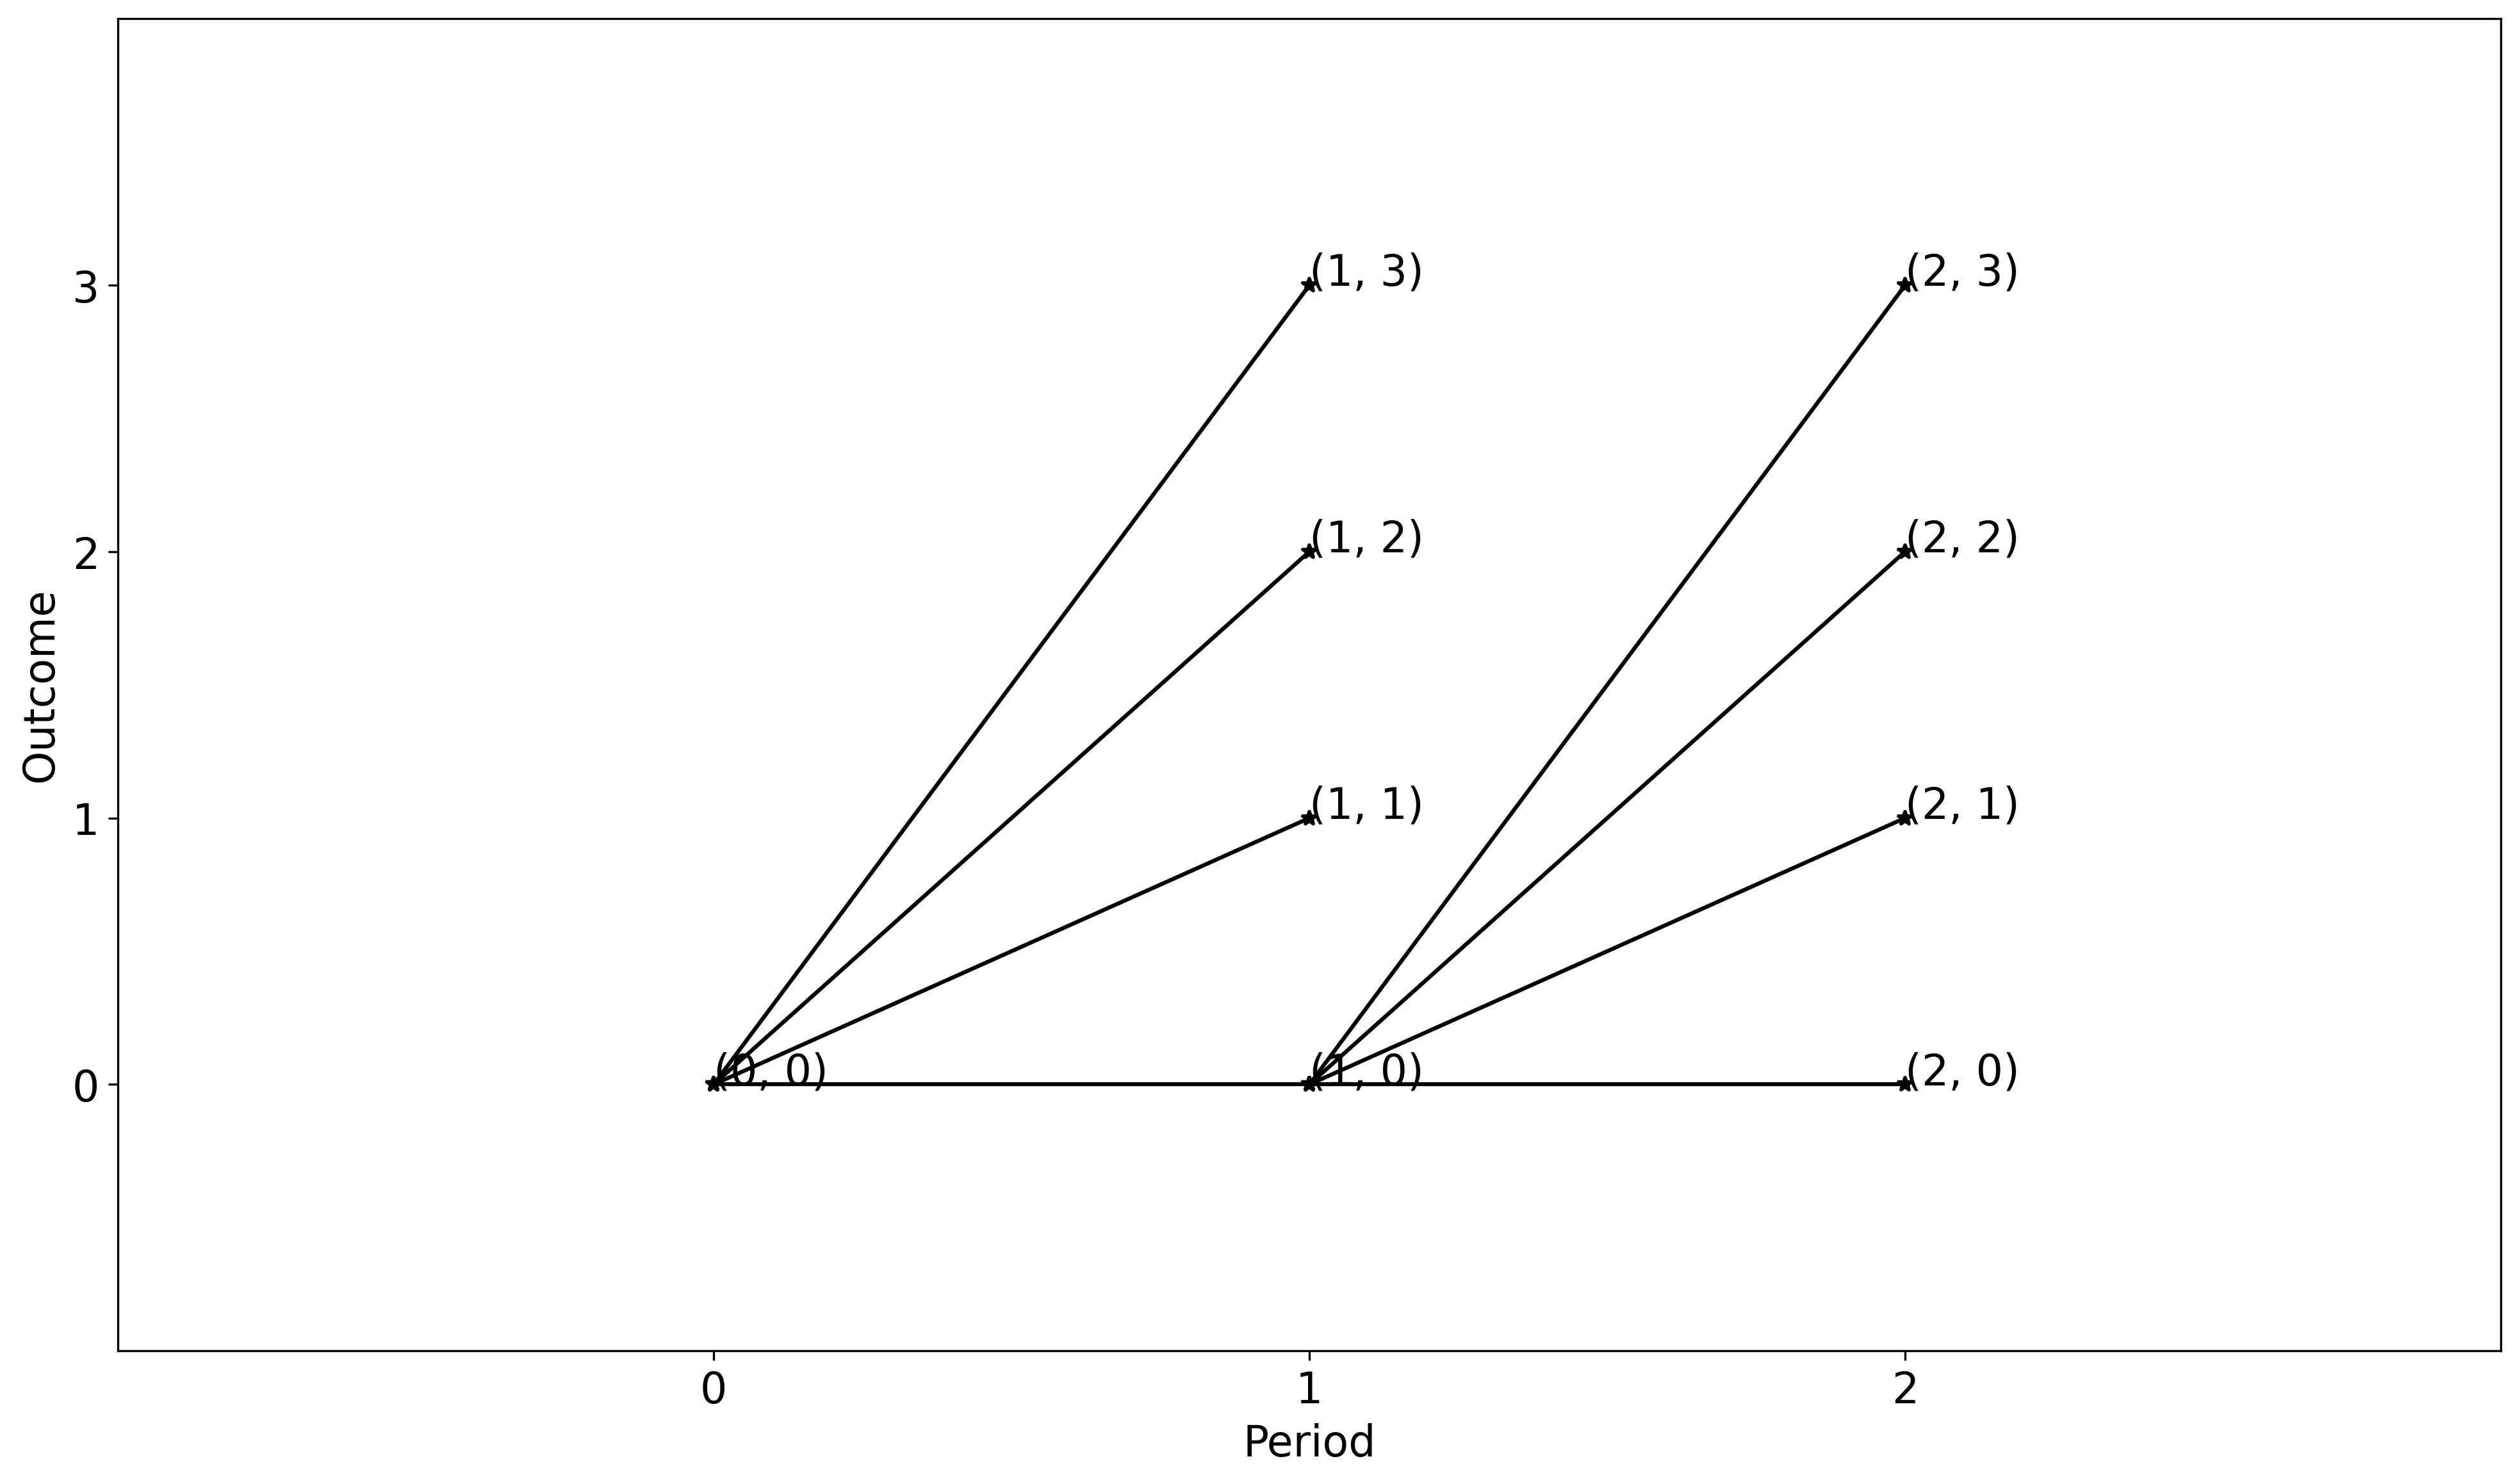

In [3]:
c = [    [(0,0),(1,0)],
         [(0,0),(1,1)],
         [(0,0),(1,2)],
         [(0,0),(1,3)],
         [(1,0),(2,0)],
         [(1,0),(2,1)],
         [(1,0),(2,2)],
         [(1,0),(2,3)]
    ] 

fig = plt.figure()
ax = fig.add_subplot(111)

annotated = set()
for l in c:
    d = [ [p[0] for p in l], [p[1] for p in l]]
    ax.plot(d[0], d[1], 'k-*')
    for p in l:
        annotated.add(p)

for p in annotated:
    ax.annotate(str(p), xy=p)

plt.xlabel('Period')
plt.xlim([-1, 3])
plt.xticks([0, 1, 2])
plt.ylabel('Outcome')
plt.ylim([-1, 4])
plt.yticks([0, 1, 2, 3])
plt.show()        


In [6]:
default_rate = data.groupby('time')['default_time'].mean().reset_index(drop=False)

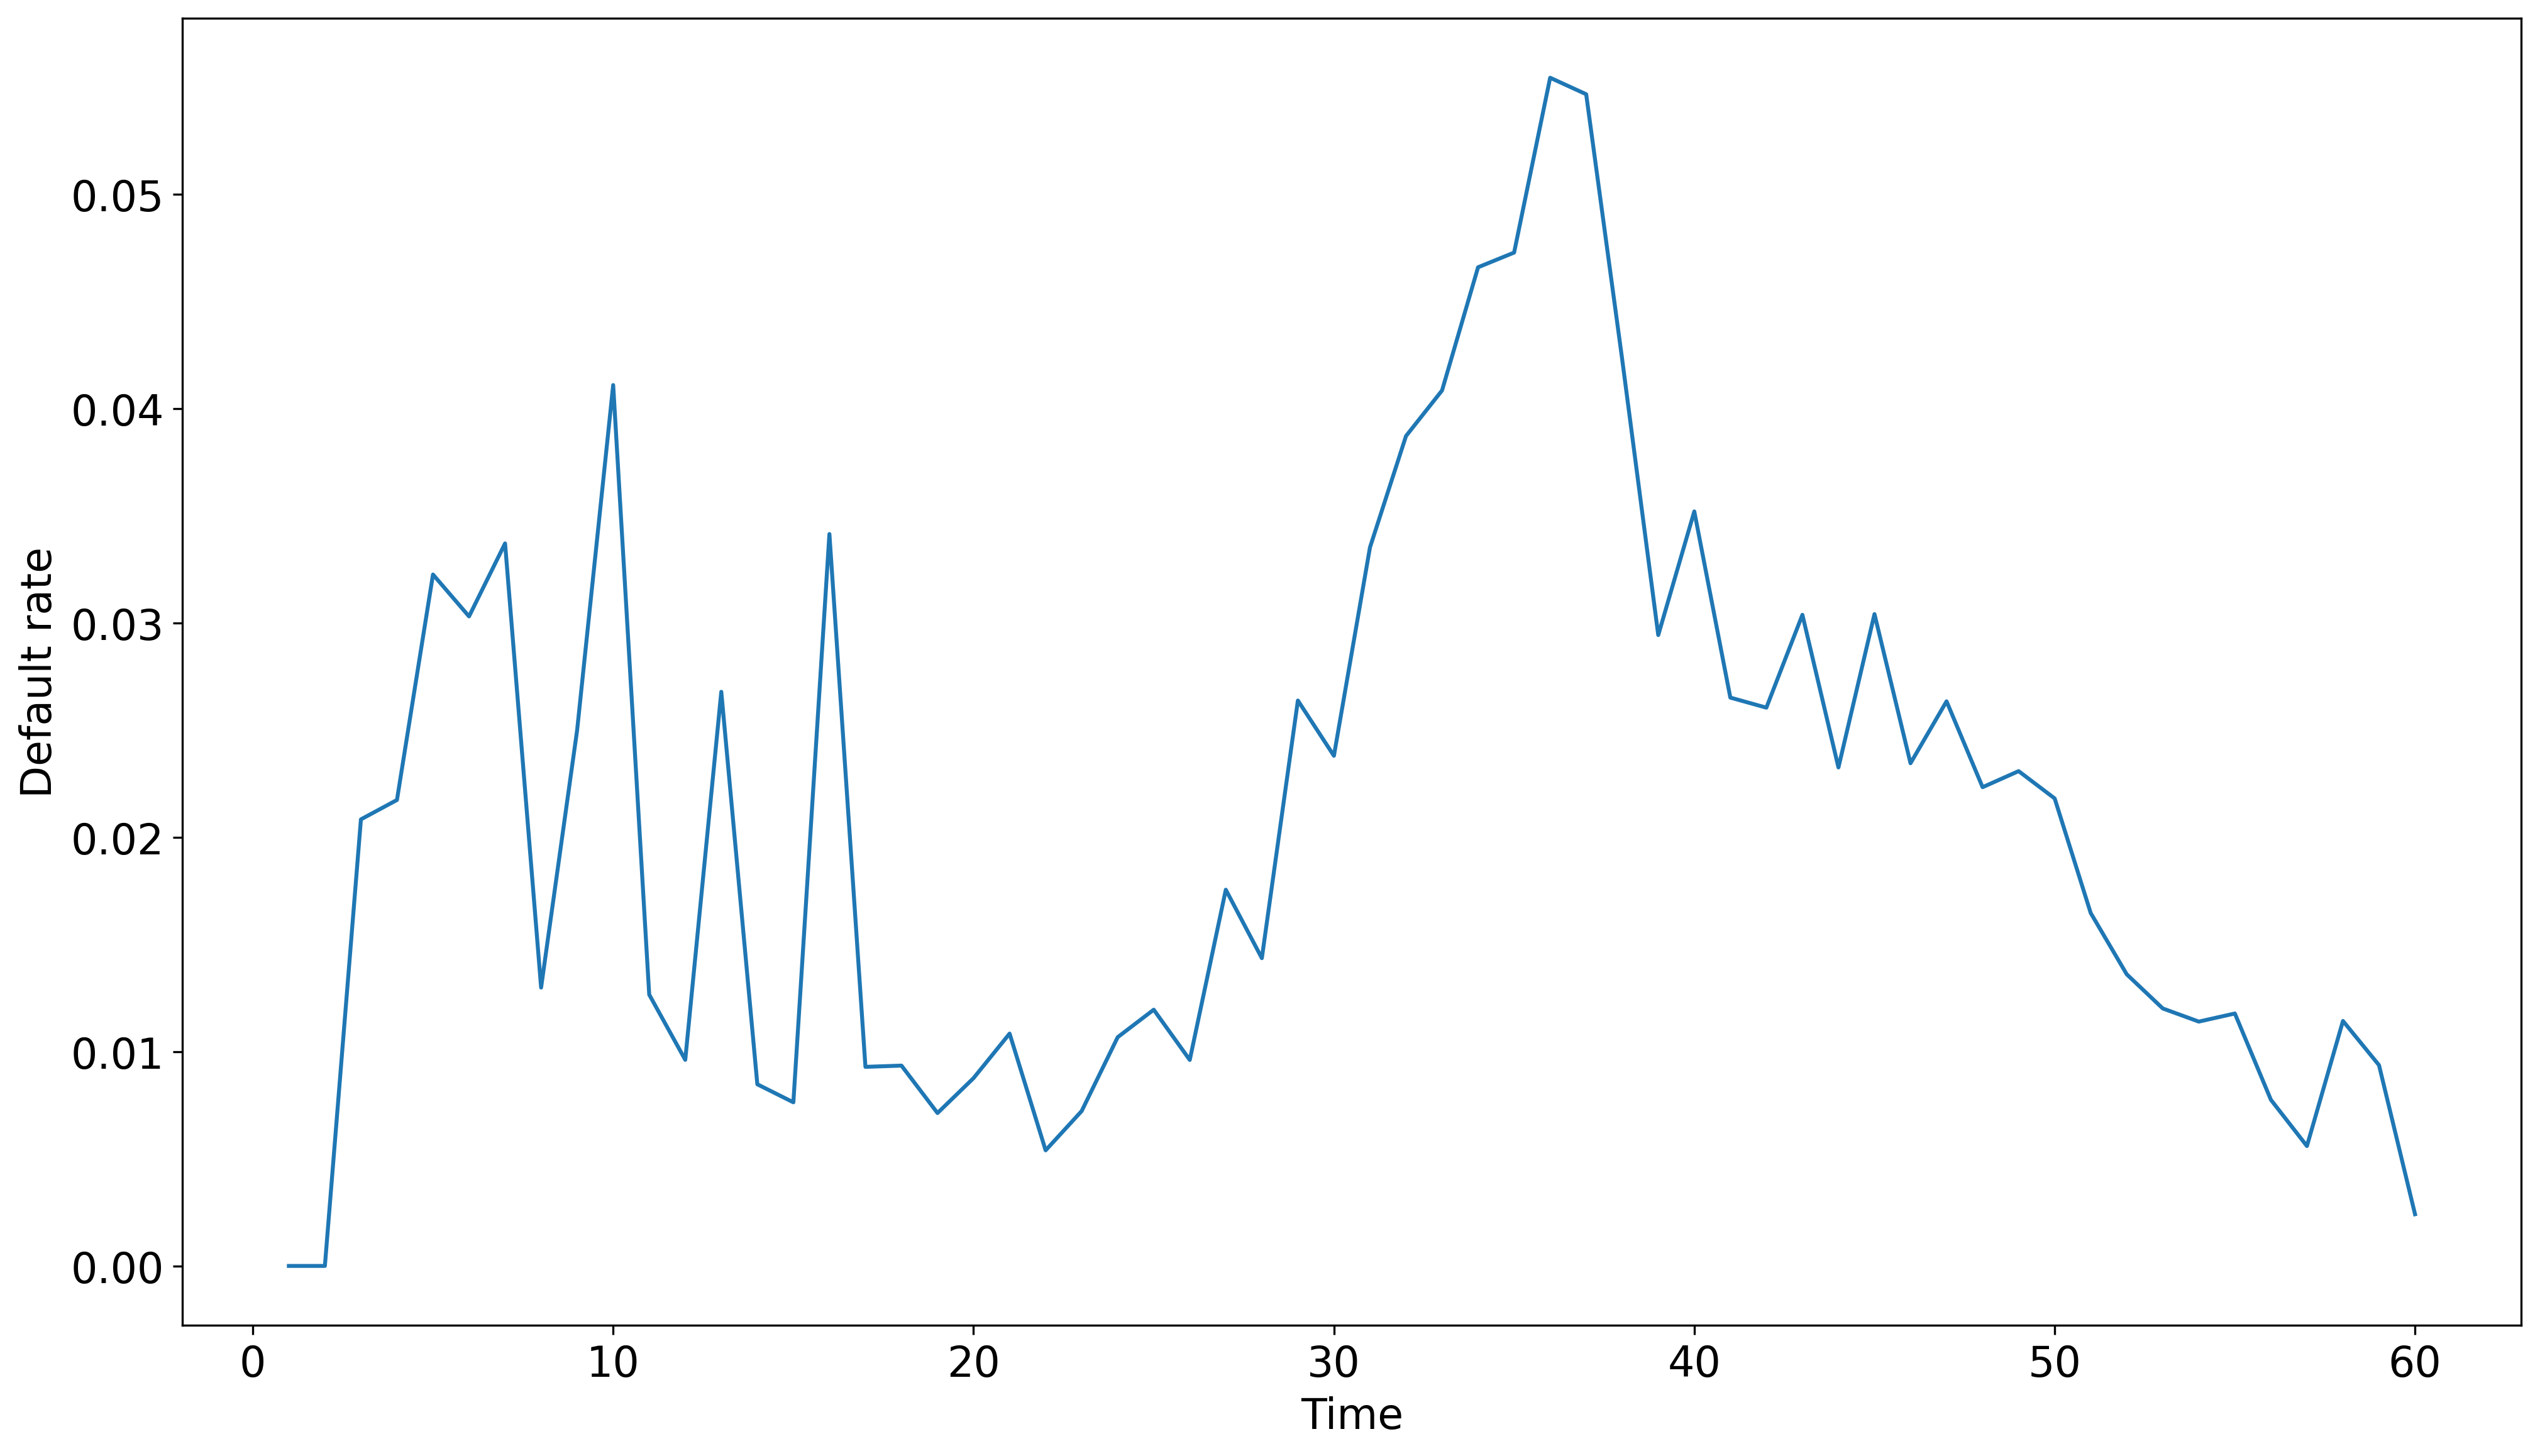

In [7]:
plt.plot('time', 'default_time', data=default_rate)
plt.xlabel('Time')
plt.ylabel('Default rate')
plt.show()

In [8]:
data.loc[:, 'orig_time2'] = data.orig_time
data.loc[data['orig_time2'] < 0, 'orig_time2'] = 0
data.loc[data['orig_time2'] >= 30, 'orig_time2'] = 30

default_rate = data.groupby('orig_time2')['default_time'].mean().reset_index(drop=False)

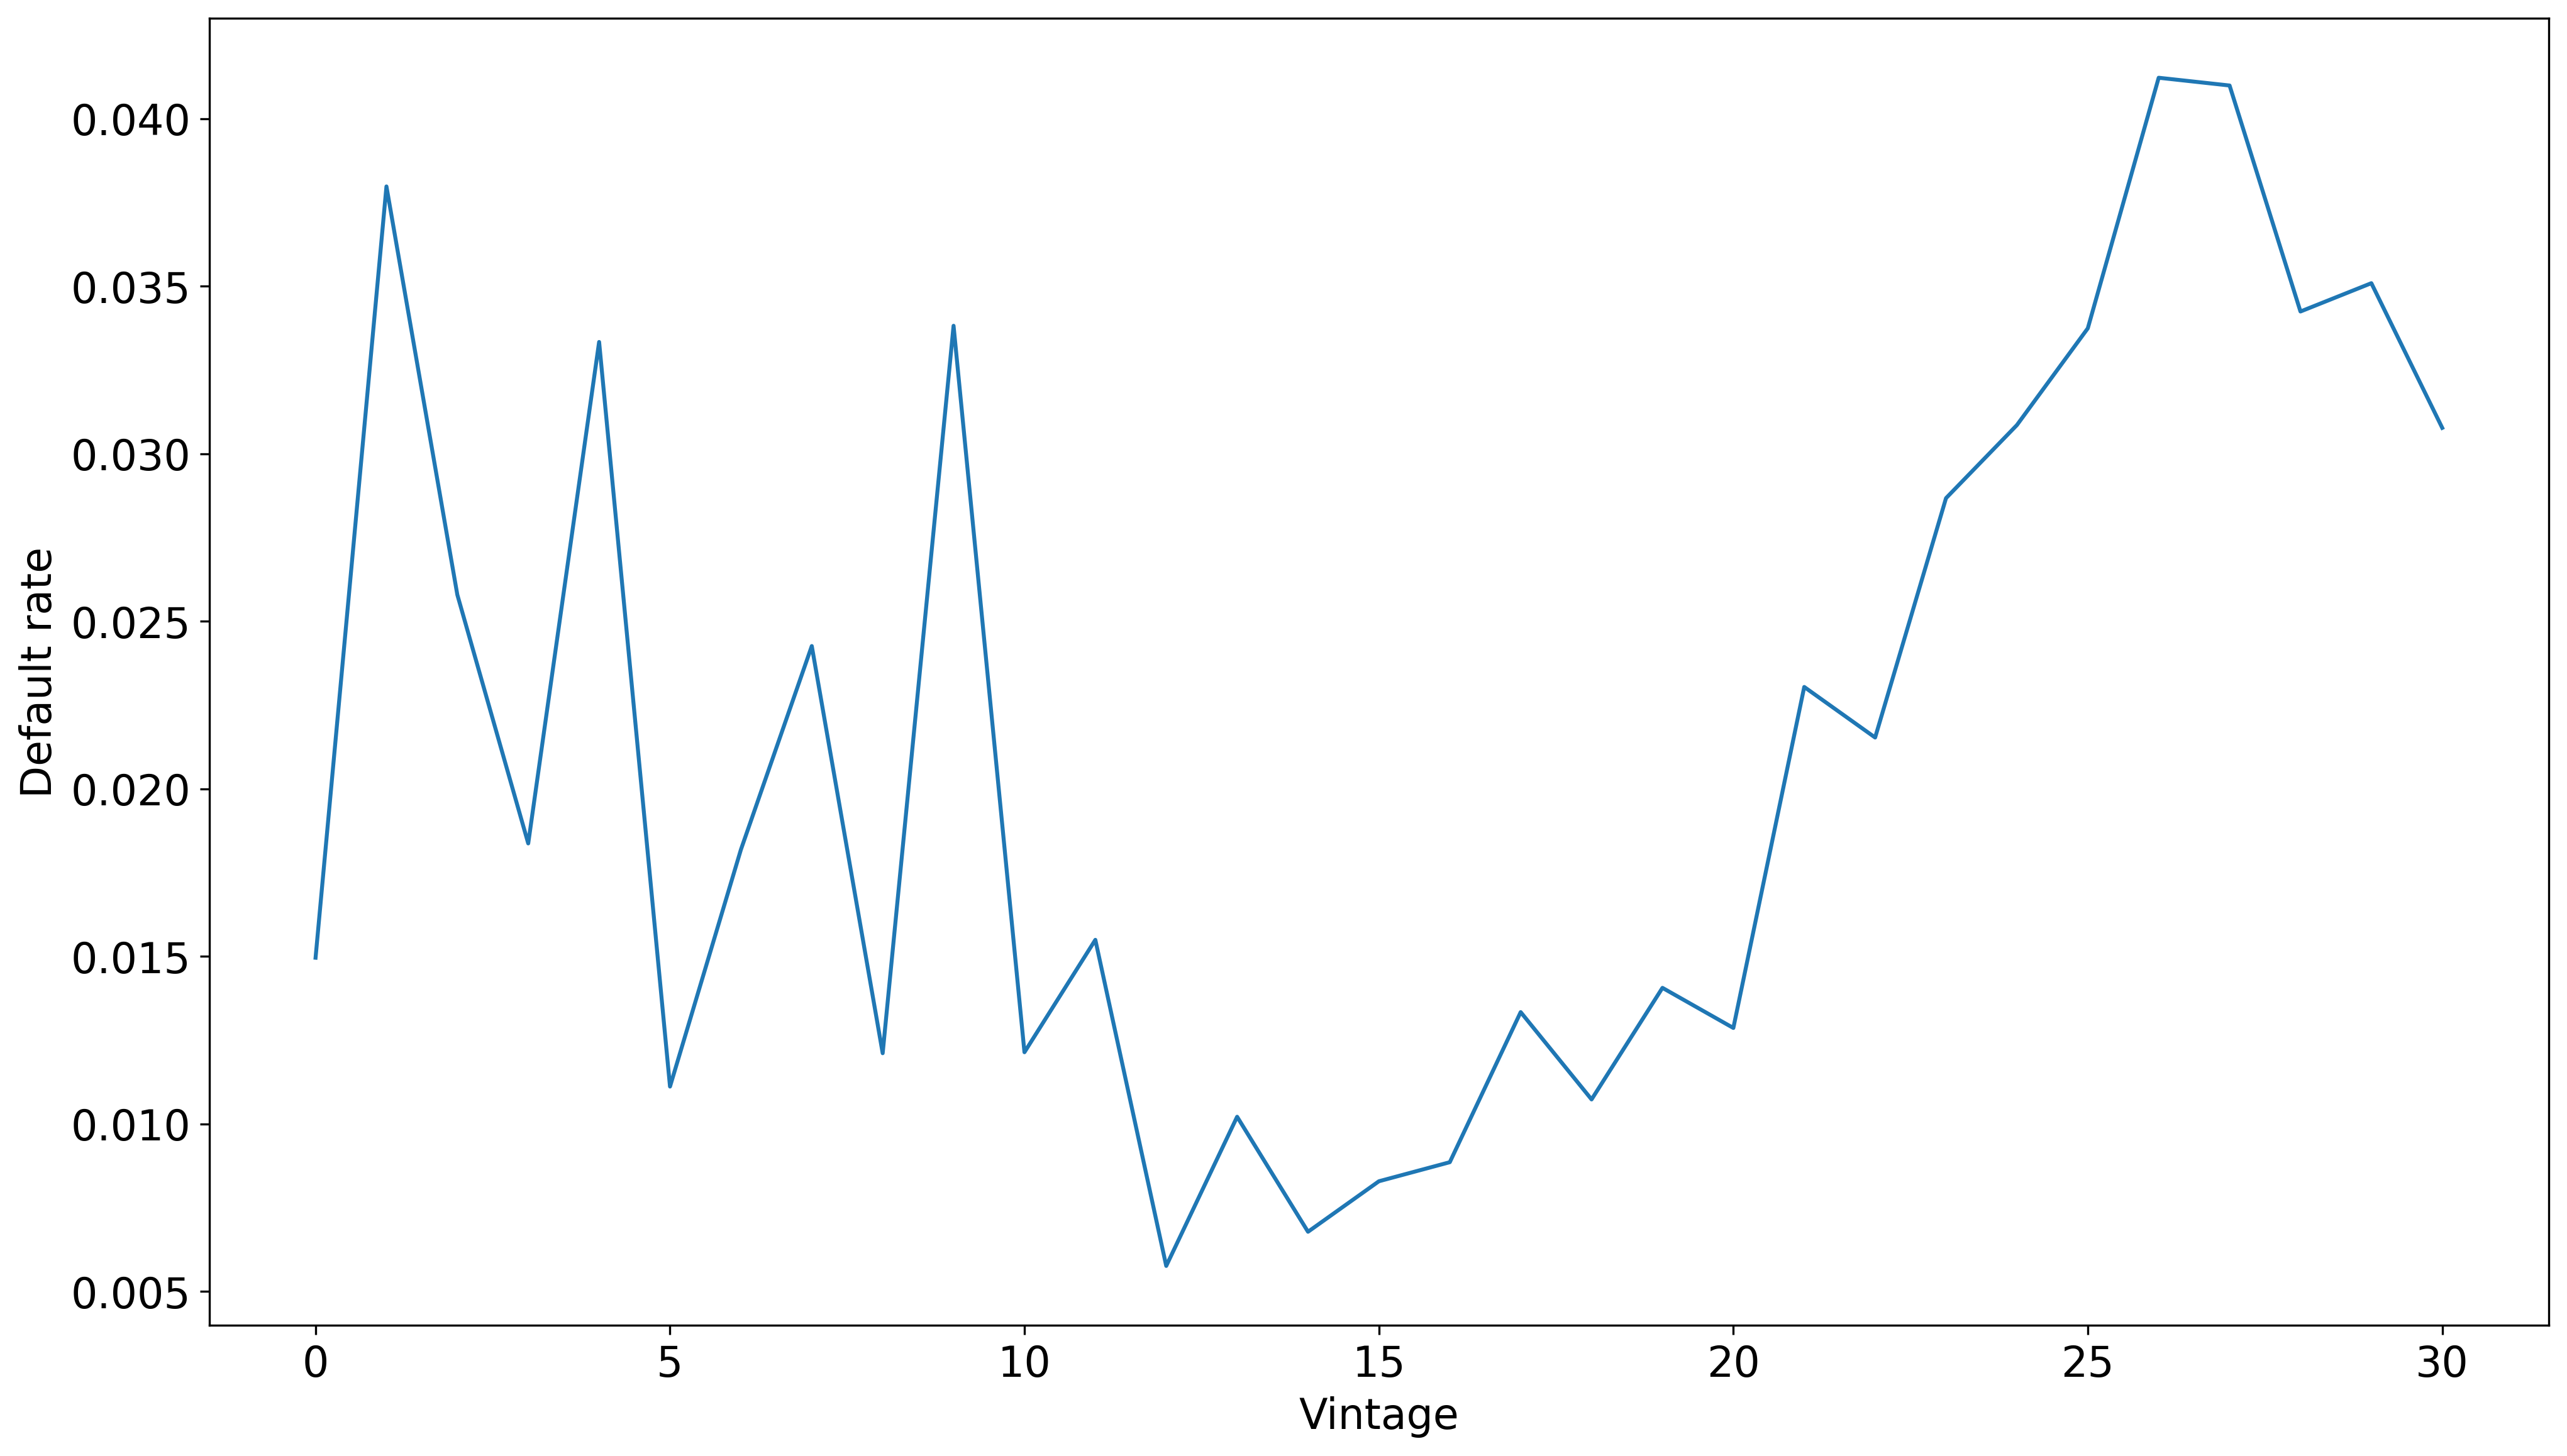

In [9]:
plt.plot('orig_time2', 'default_time', data=default_rate)
plt.xlabel('Vintage')
plt.ylabel('Default rate')
plt.show()

In [10]:
data.loc[:, 'age'] = data.loc[:, 'time']-data.loc[:, 'orig_time']
data.loc[data['age'] >= 40, 'age'] = 40
data.loc[:, 'age2'] = data.loc[:, 'age'].multiply(data.loc[:, 'age'])

data_mean_age = data.groupby('age')['default_time'].mean().reset_index(drop=False)

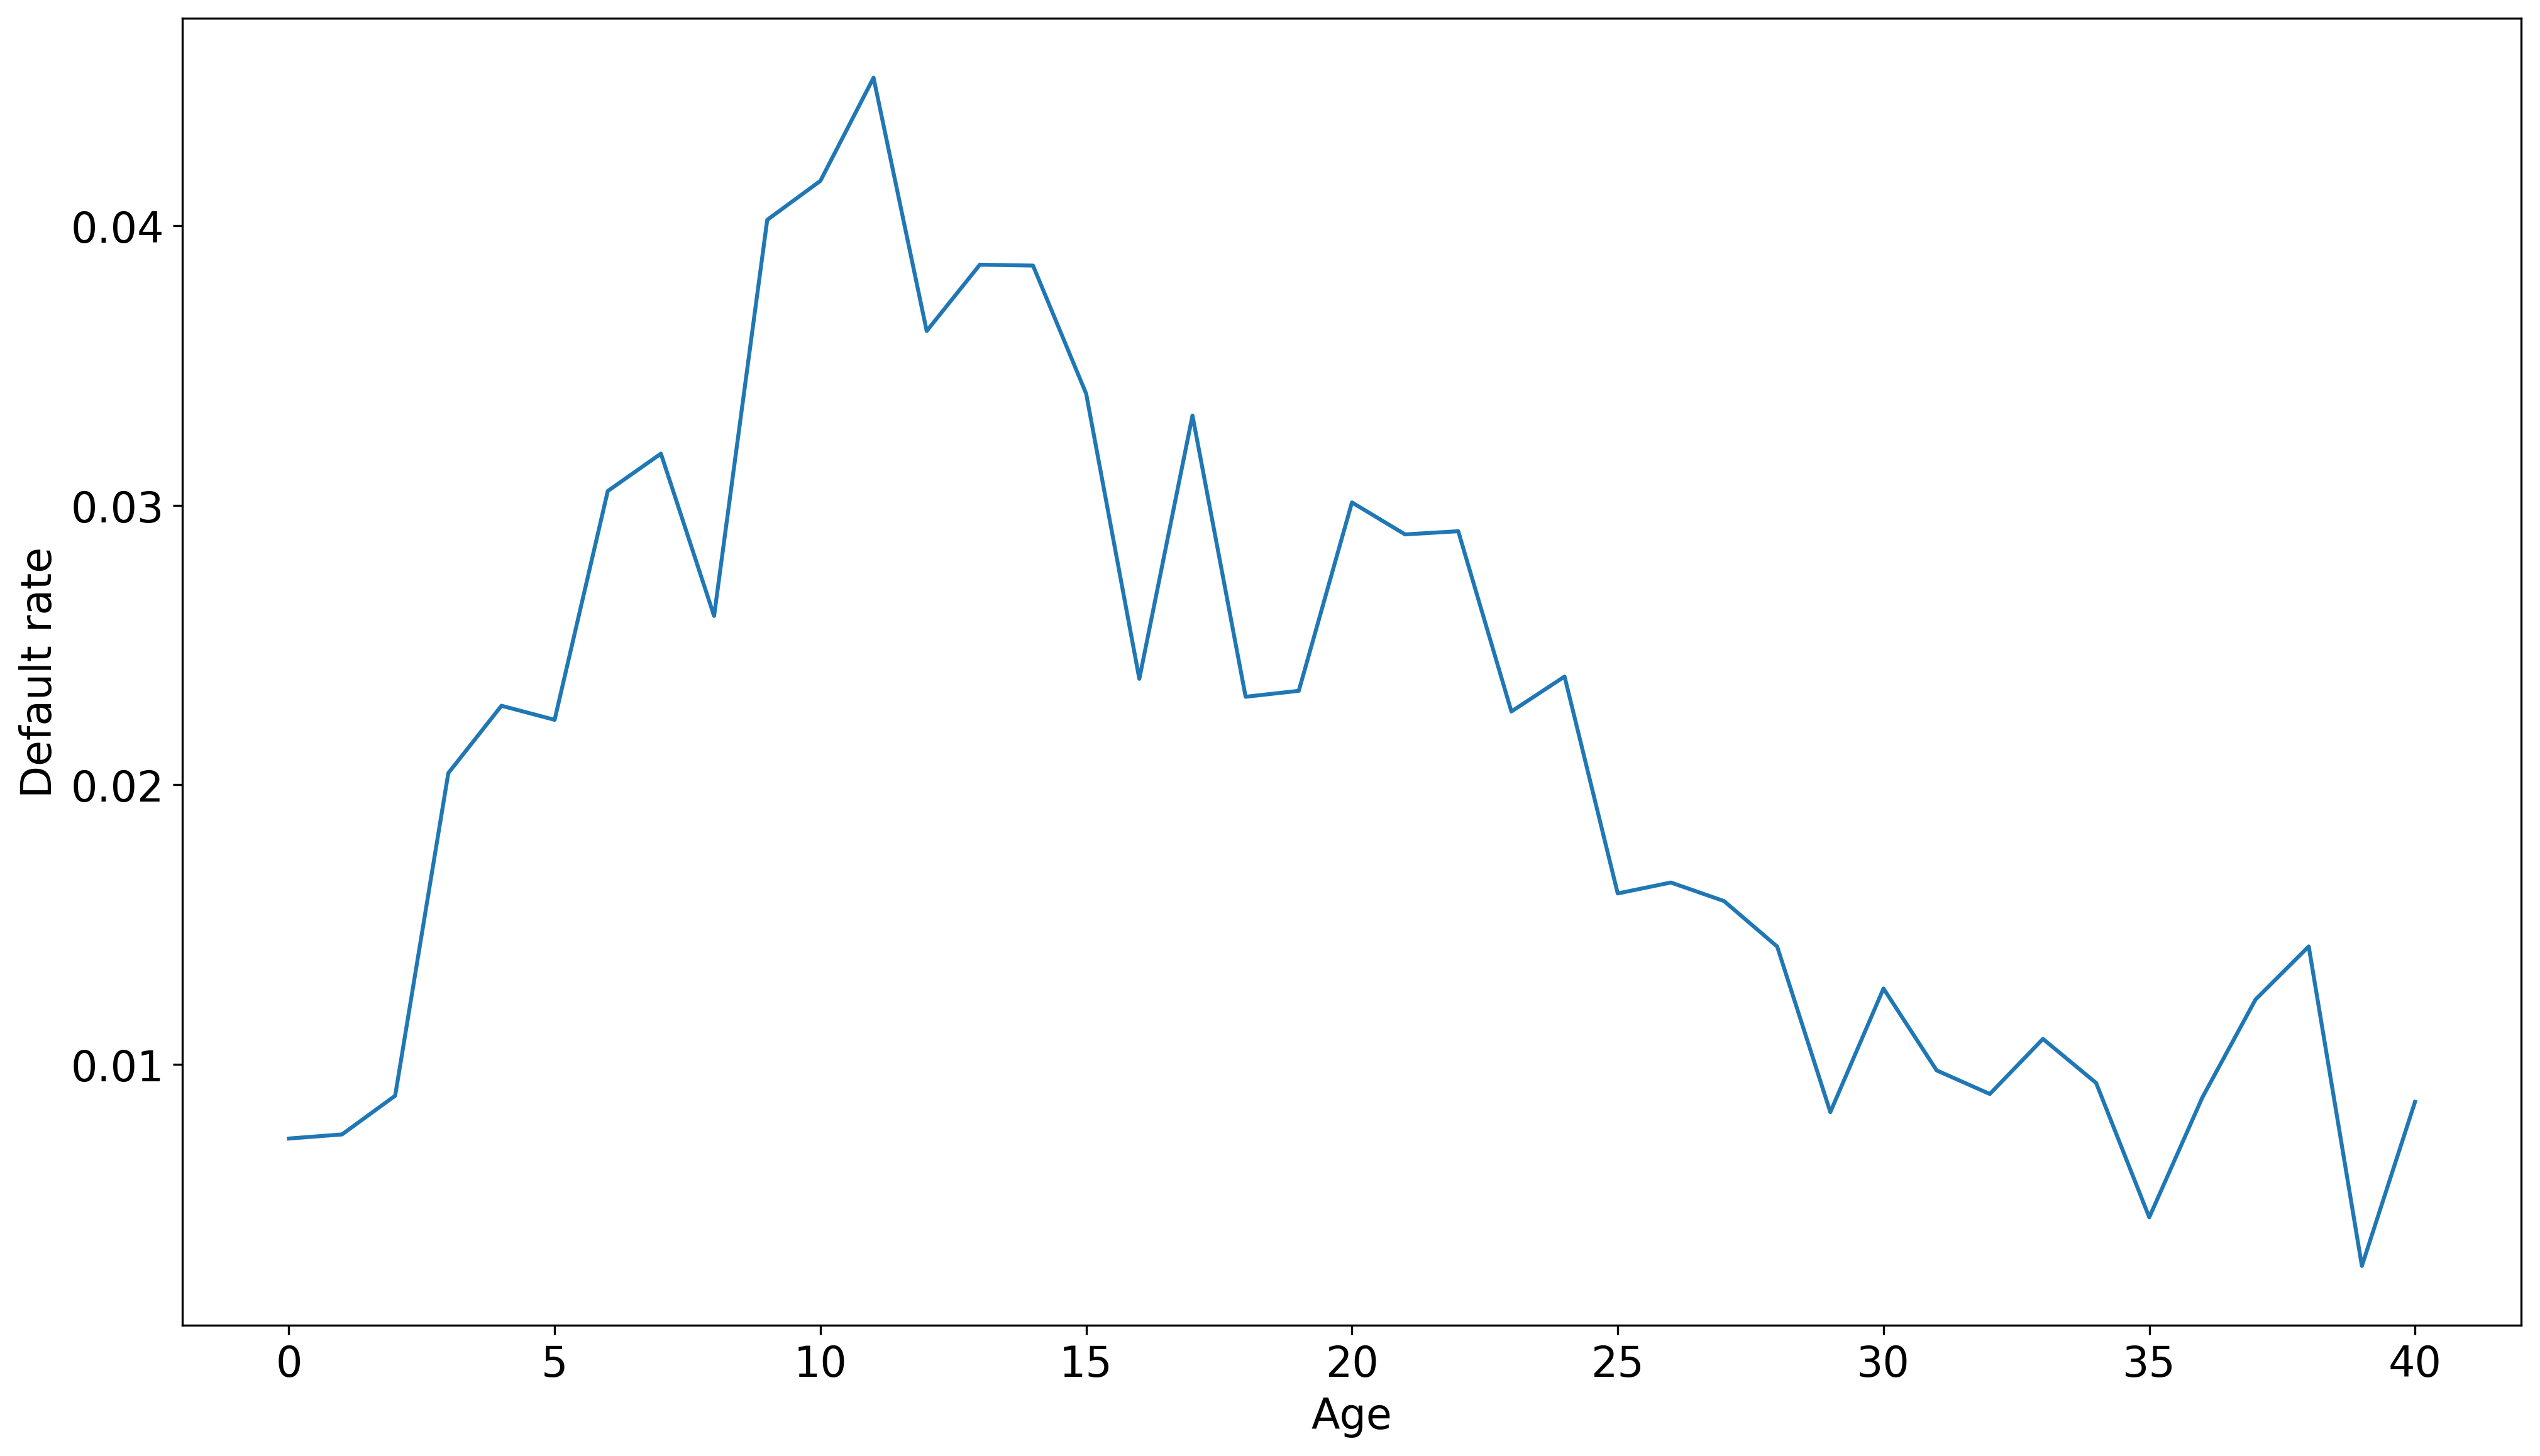

In [11]:
plt.plot('age', 'default_time', data=data_mean_age)
plt.xlabel('Age')
plt.ylabel('Default rate')
plt.show()

In [12]:
data = data.sort_values(by=['id', 'time'])  

data.loc[:,'default_time_1'] = data.groupby(['id'])['default_time'].shift(-1)  
data.loc[:,'default_time_2'] = data.groupby(['id'])['default_time'].shift(-2) 

print(data.loc[(data.id == 9)|(data.id == 47),['id', 'time', 'default_time', 'default_time_1', 'default_time_2']])

    id  time  default_time  default_time_1  default_time_2
35   9    25             0             0.0             0.0
36   9    26             0             0.0             0.0
37   9    27             0             0.0             0.0
38   9    28             0             0.0             0.0
39   9    29             0             0.0             0.0
..  ..   ...           ...             ...             ...
46   9    36             0             1.0             NaN
47   9    37             1             NaN             NaN
48  47    25             0             0.0             0.0
49  47    26             0             0.0             NaN
50  47    27             0             NaN             NaN

[16 rows x 5 columns]


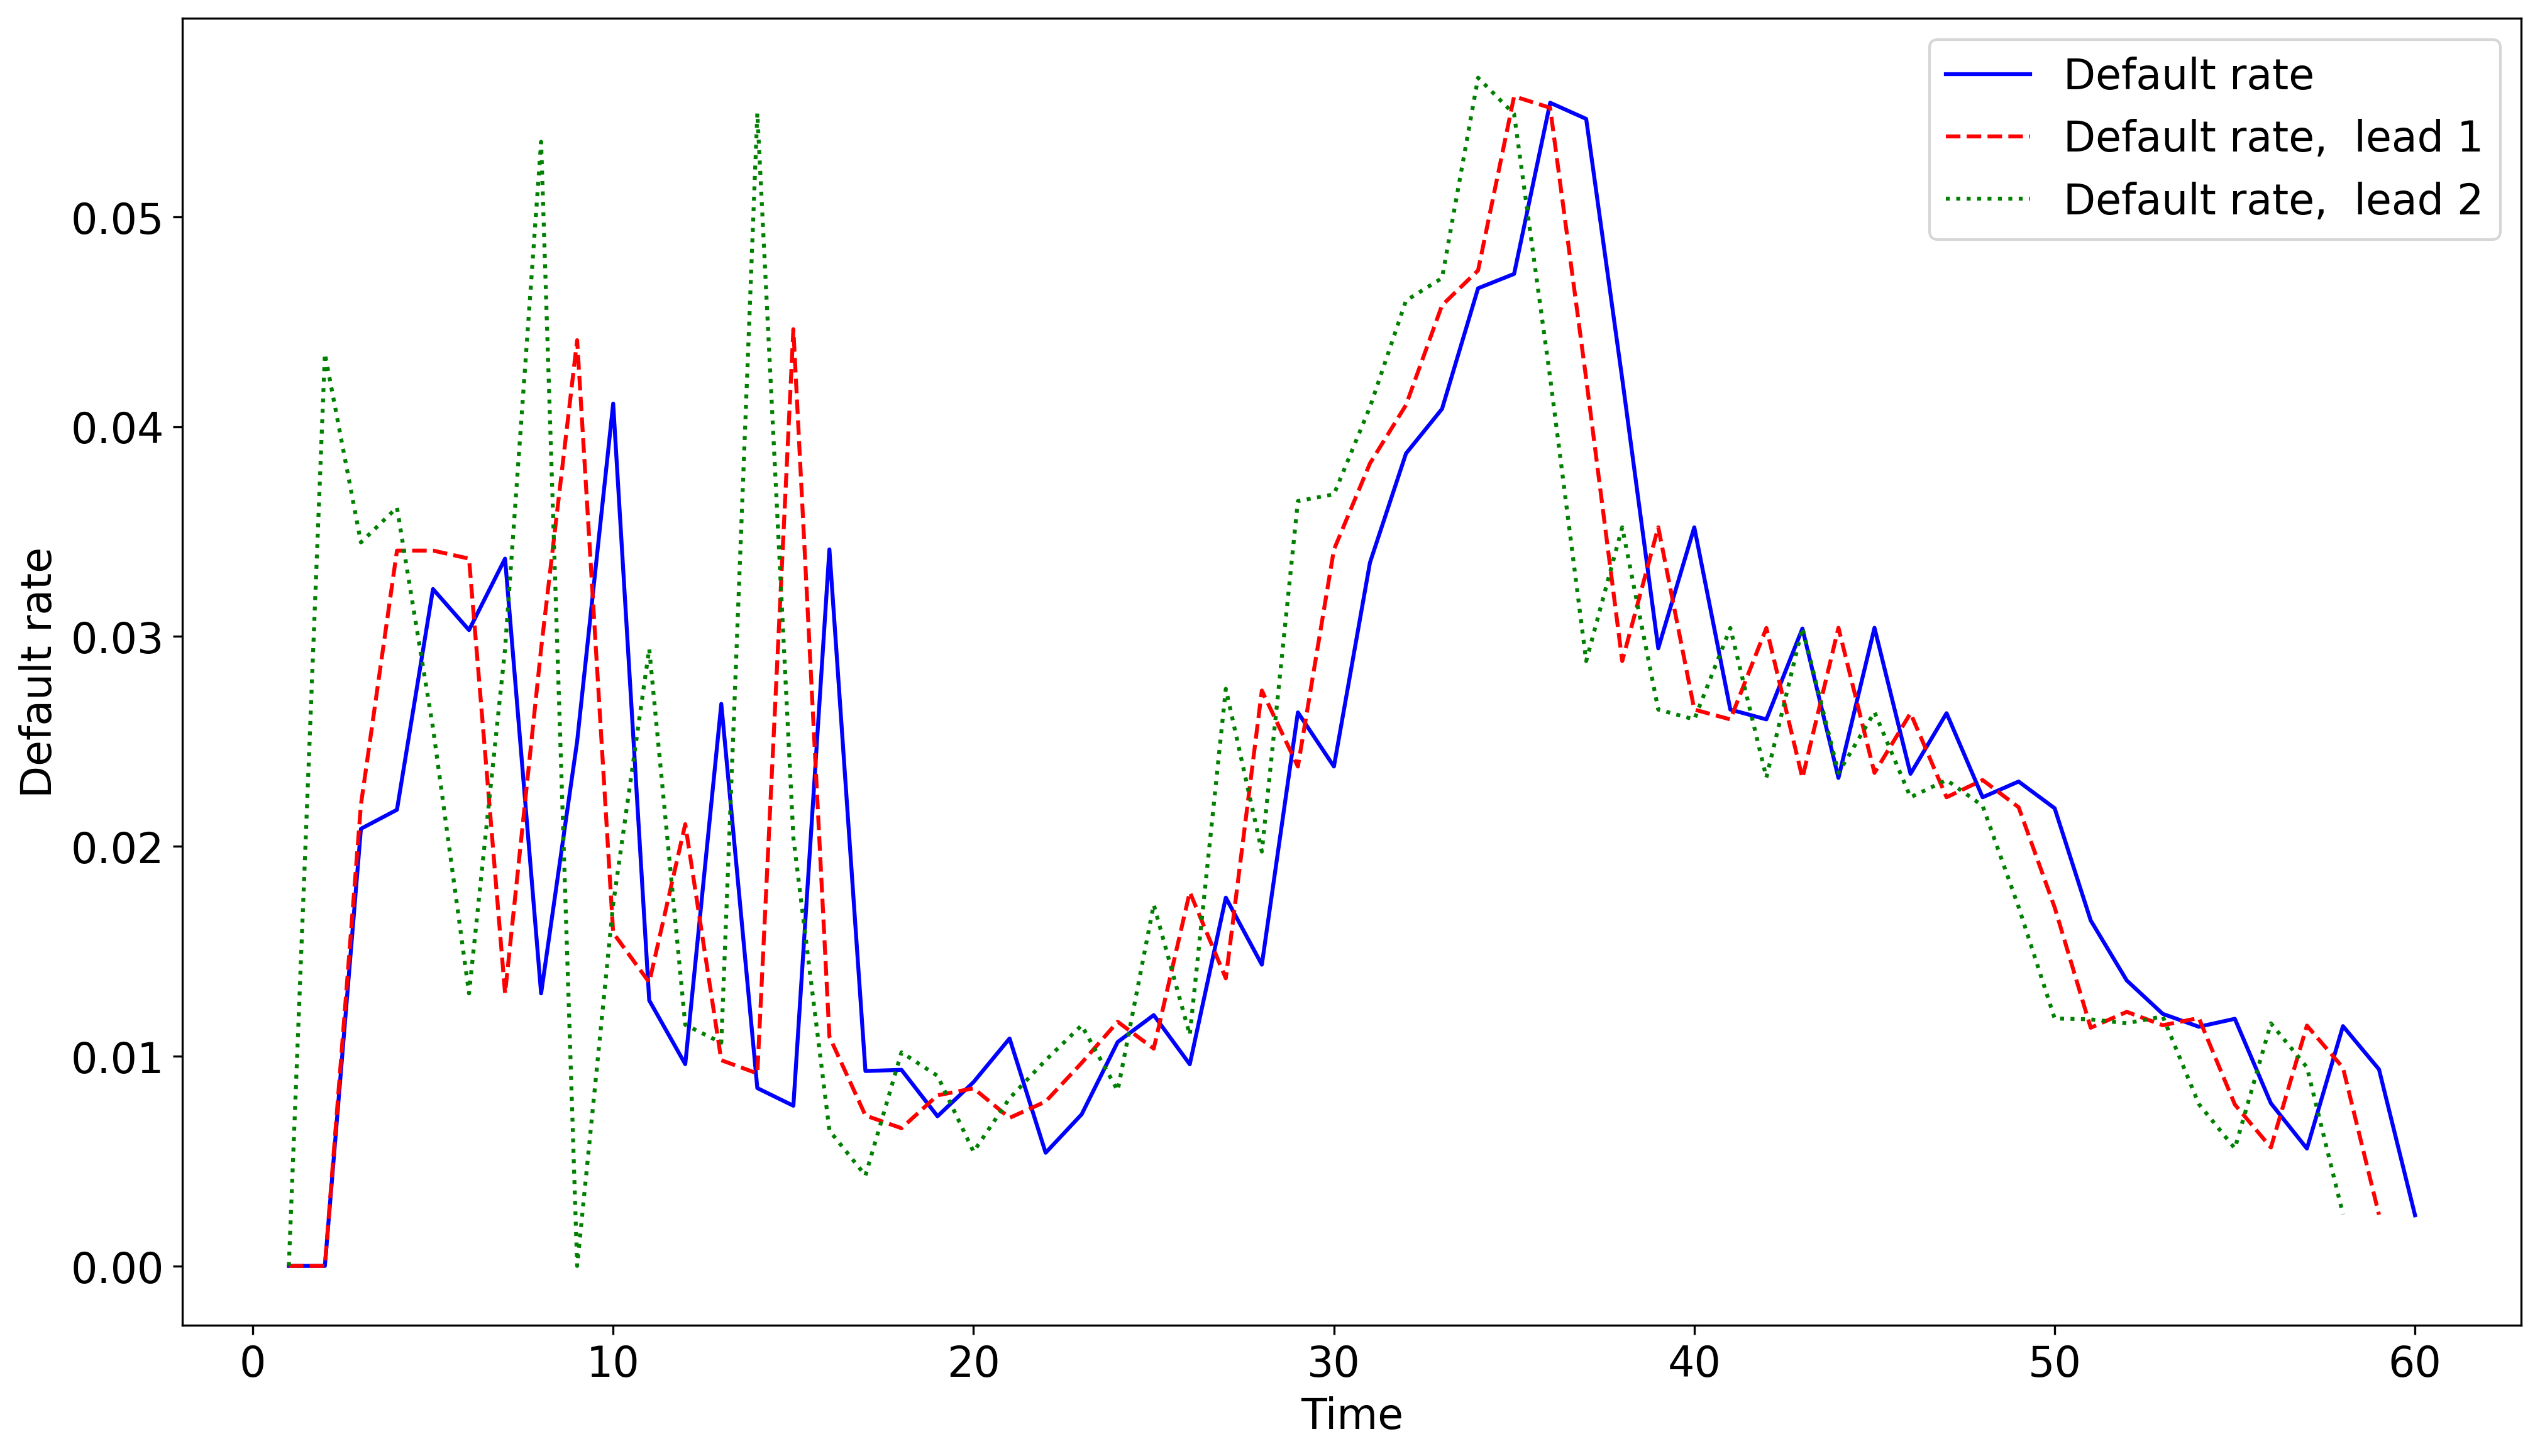

In [13]:
default_rate = data.groupby('time')['default_time'].mean().reset_index(drop=False)  
default_rate_1 = data.groupby('time')['default_time_1'].mean().reset_index(drop=False)  
default_rate_2 = data.groupby('time')['default_time_2'].mean().reset_index(drop=False)  

plt.plot('time', 'default_time', data=default_rate, color='blue', label='Default rate')  
plt.plot('time', 'default_time_1', data=default_rate_1, color='red', label='Default rate,  lead 1', ls='dashed')  
plt.plot('time', 'default_time_2', data=default_rate_2, color='green', label='Default rate,  lead 2', ls='dotted')  
plt.xlabel('Time')  
plt.ylabel('Default rate')  
plt.legend(loc='best')  
plt.show() 

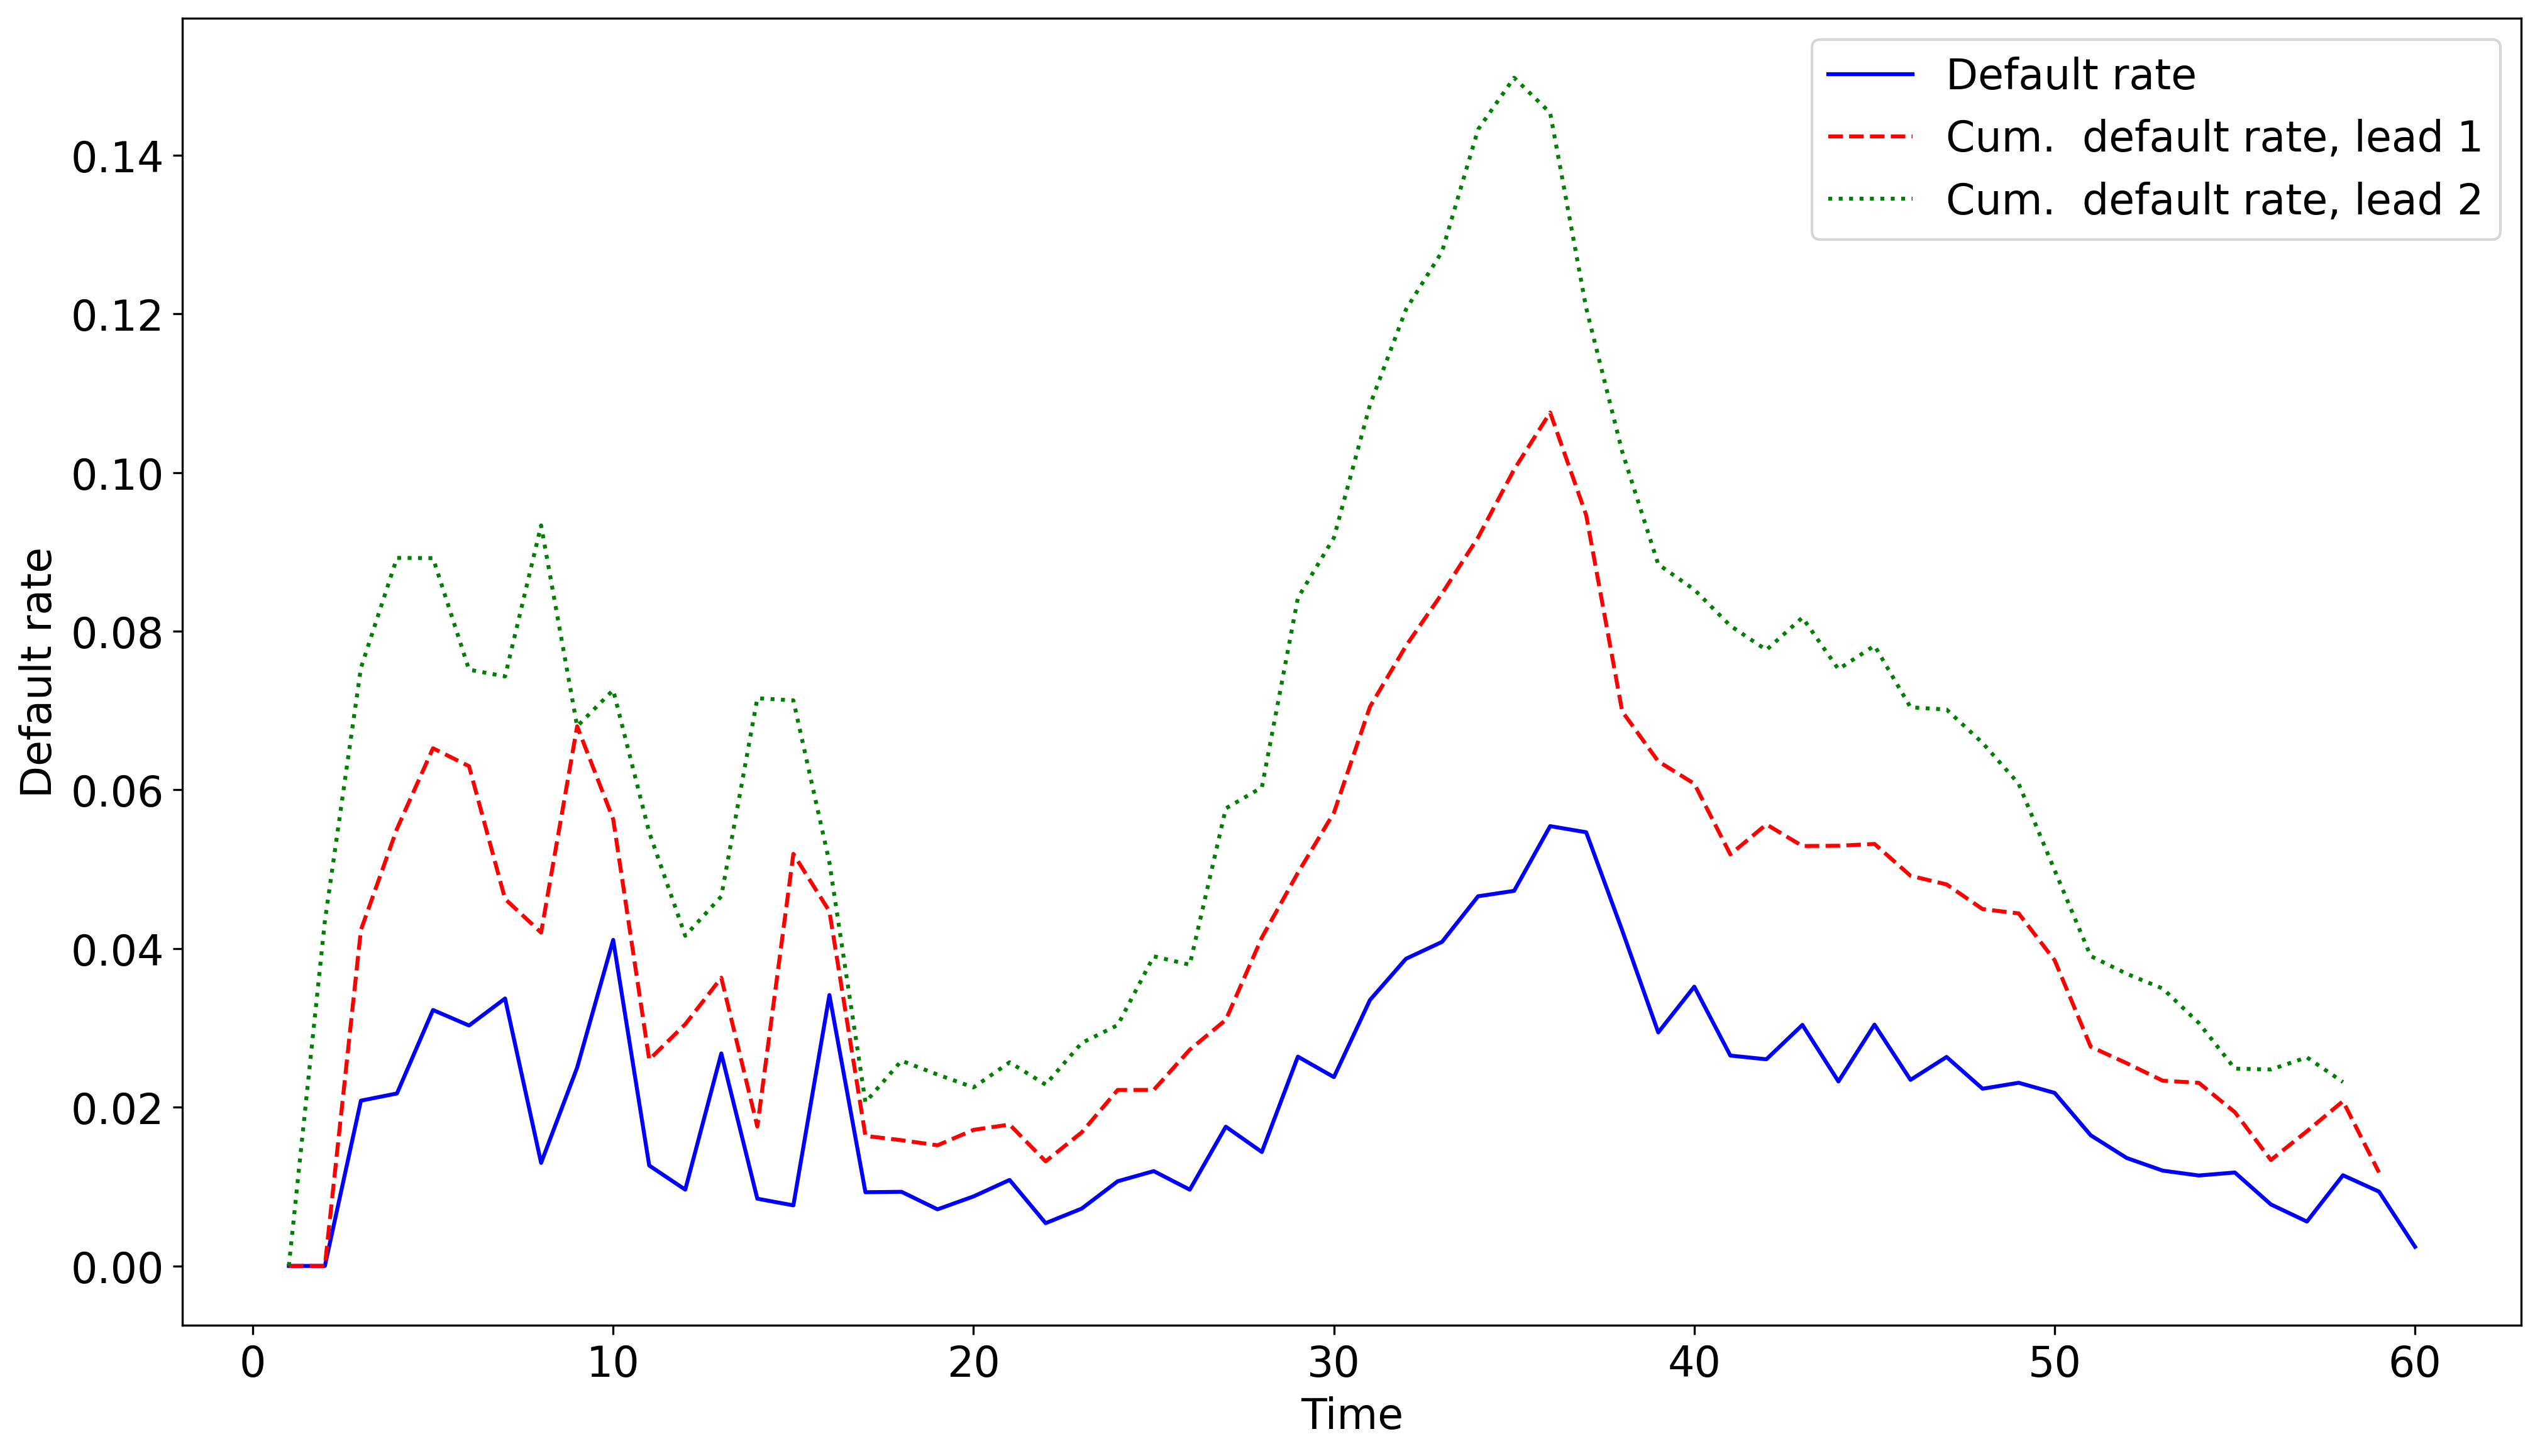

In [14]:
default_rate_1['cum_default_time_1'] = default_rate.loc[:,'default_time'] + (1-default_rate  .loc[:,'default_time']) * default_rate_1.loc[:,'default_time_1']
default_rate_2['cum_default_time_2'] = default_rate.loc[:,'default_time'] + (1-default_rate  .loc[:,'default_time']) * default_rate_1.loc[:,'default_time_1'] + (1-default_rate.loc  [:,'default_time']) * (1-default_rate_1.loc[:,'default_time_1']) * default_rate_2.loc[:,'default_time_2'] 
plt.plot('time', 'default_time', data=default_rate, color='blue', label='Default rate')  
plt.plot('time', 'cum_default_time_1', data=default_rate_1, color='red', label='Cum.  default rate, lead 1', ls='dashed')  
plt.plot('time', 'cum_default_time_2', data=default_rate_2, color='green', label='Cum.  default rate, lead 2', ls='dotted')  
plt.xlabel('Time')  
plt.ylabel('Default rate')  
plt.legend(loc='best')  
plt.show() 


In [15]:
data,_,_,_,_,_,_ = dataprep(data)
data['PD'] = data['default_time'].mean()

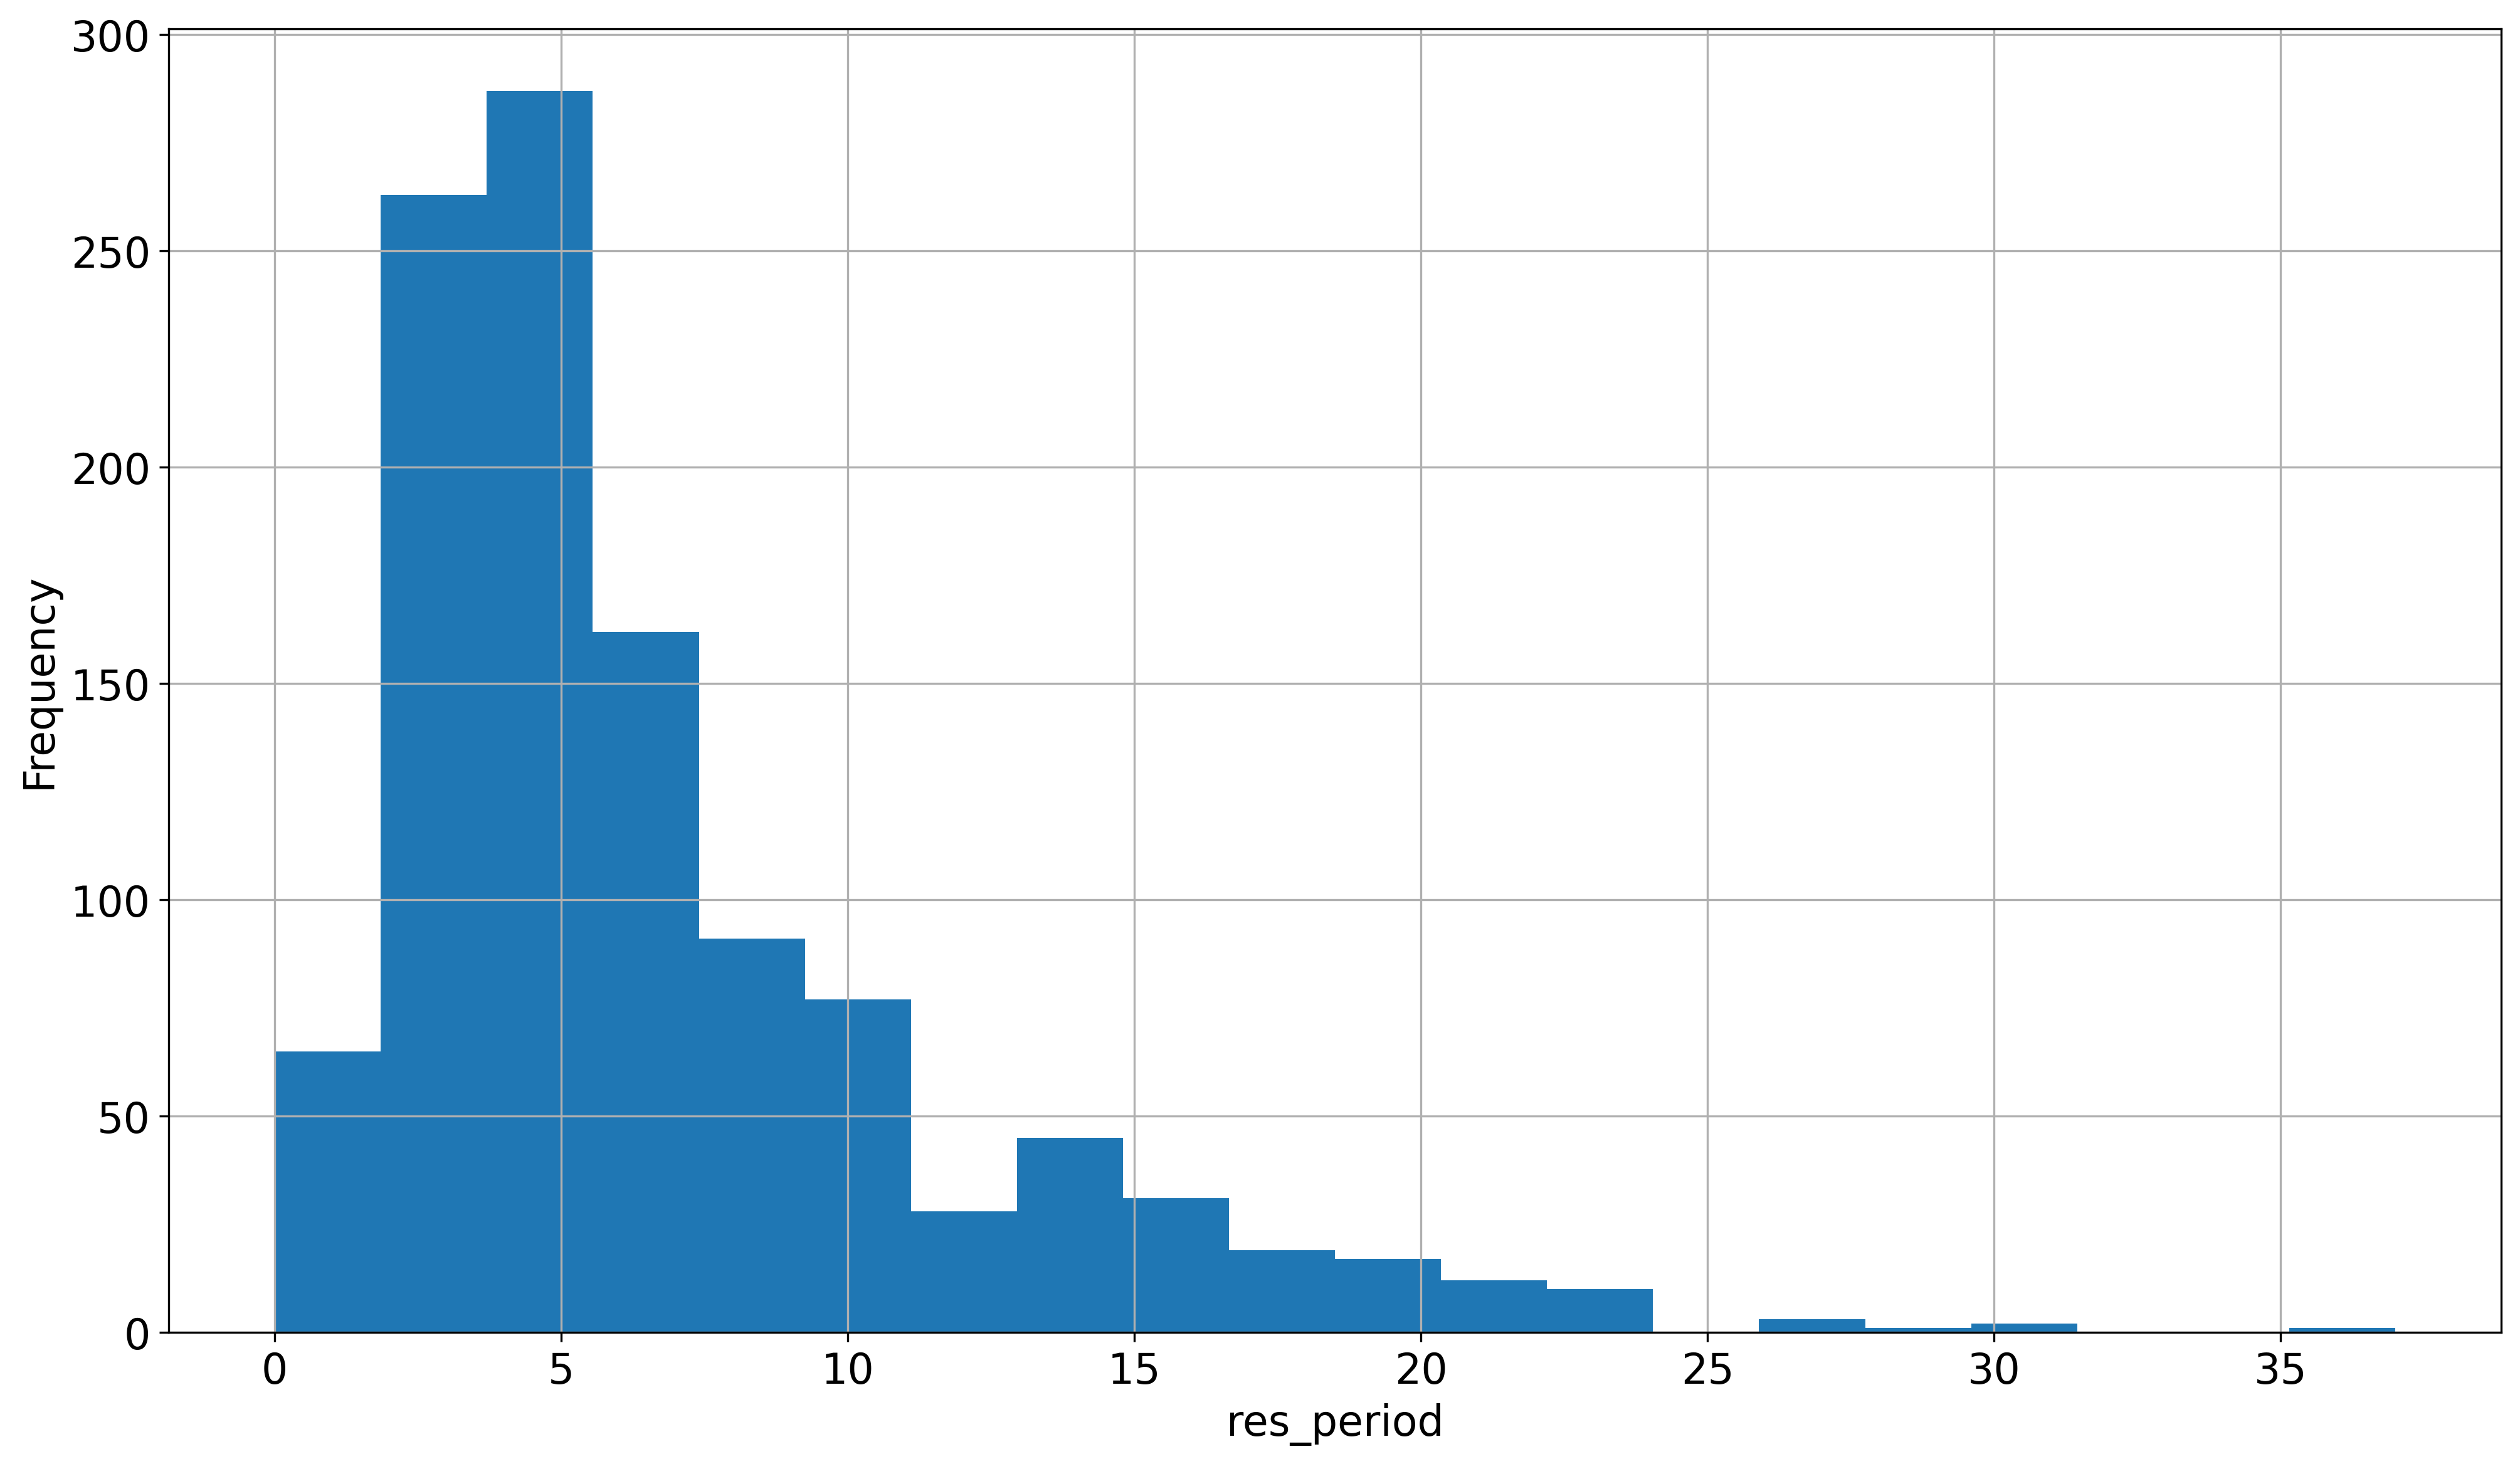

In [17]:
data_default = data.loc[data['default_time'] == 1,:].copy()  
data_default.loc[:,'res_period'] = data_default.loc[:,'res_time'] - data_default.loc[:,'time']  
data_default.loc[:,'res_period'].hist(bins=20)  
plt.xlabel('res_period')  
plt.ylabel('Frequency')  
plt.show() 


In [18]:
print(data_default.loc[:,'res_period'].describe().round(decimals=2)) 

count    1114.00
mean        6.64
std         5.11
min         0.00
25%         3.00
50%         5.00
75%         8.00
max        37.00
Name: res_period, dtype: float64


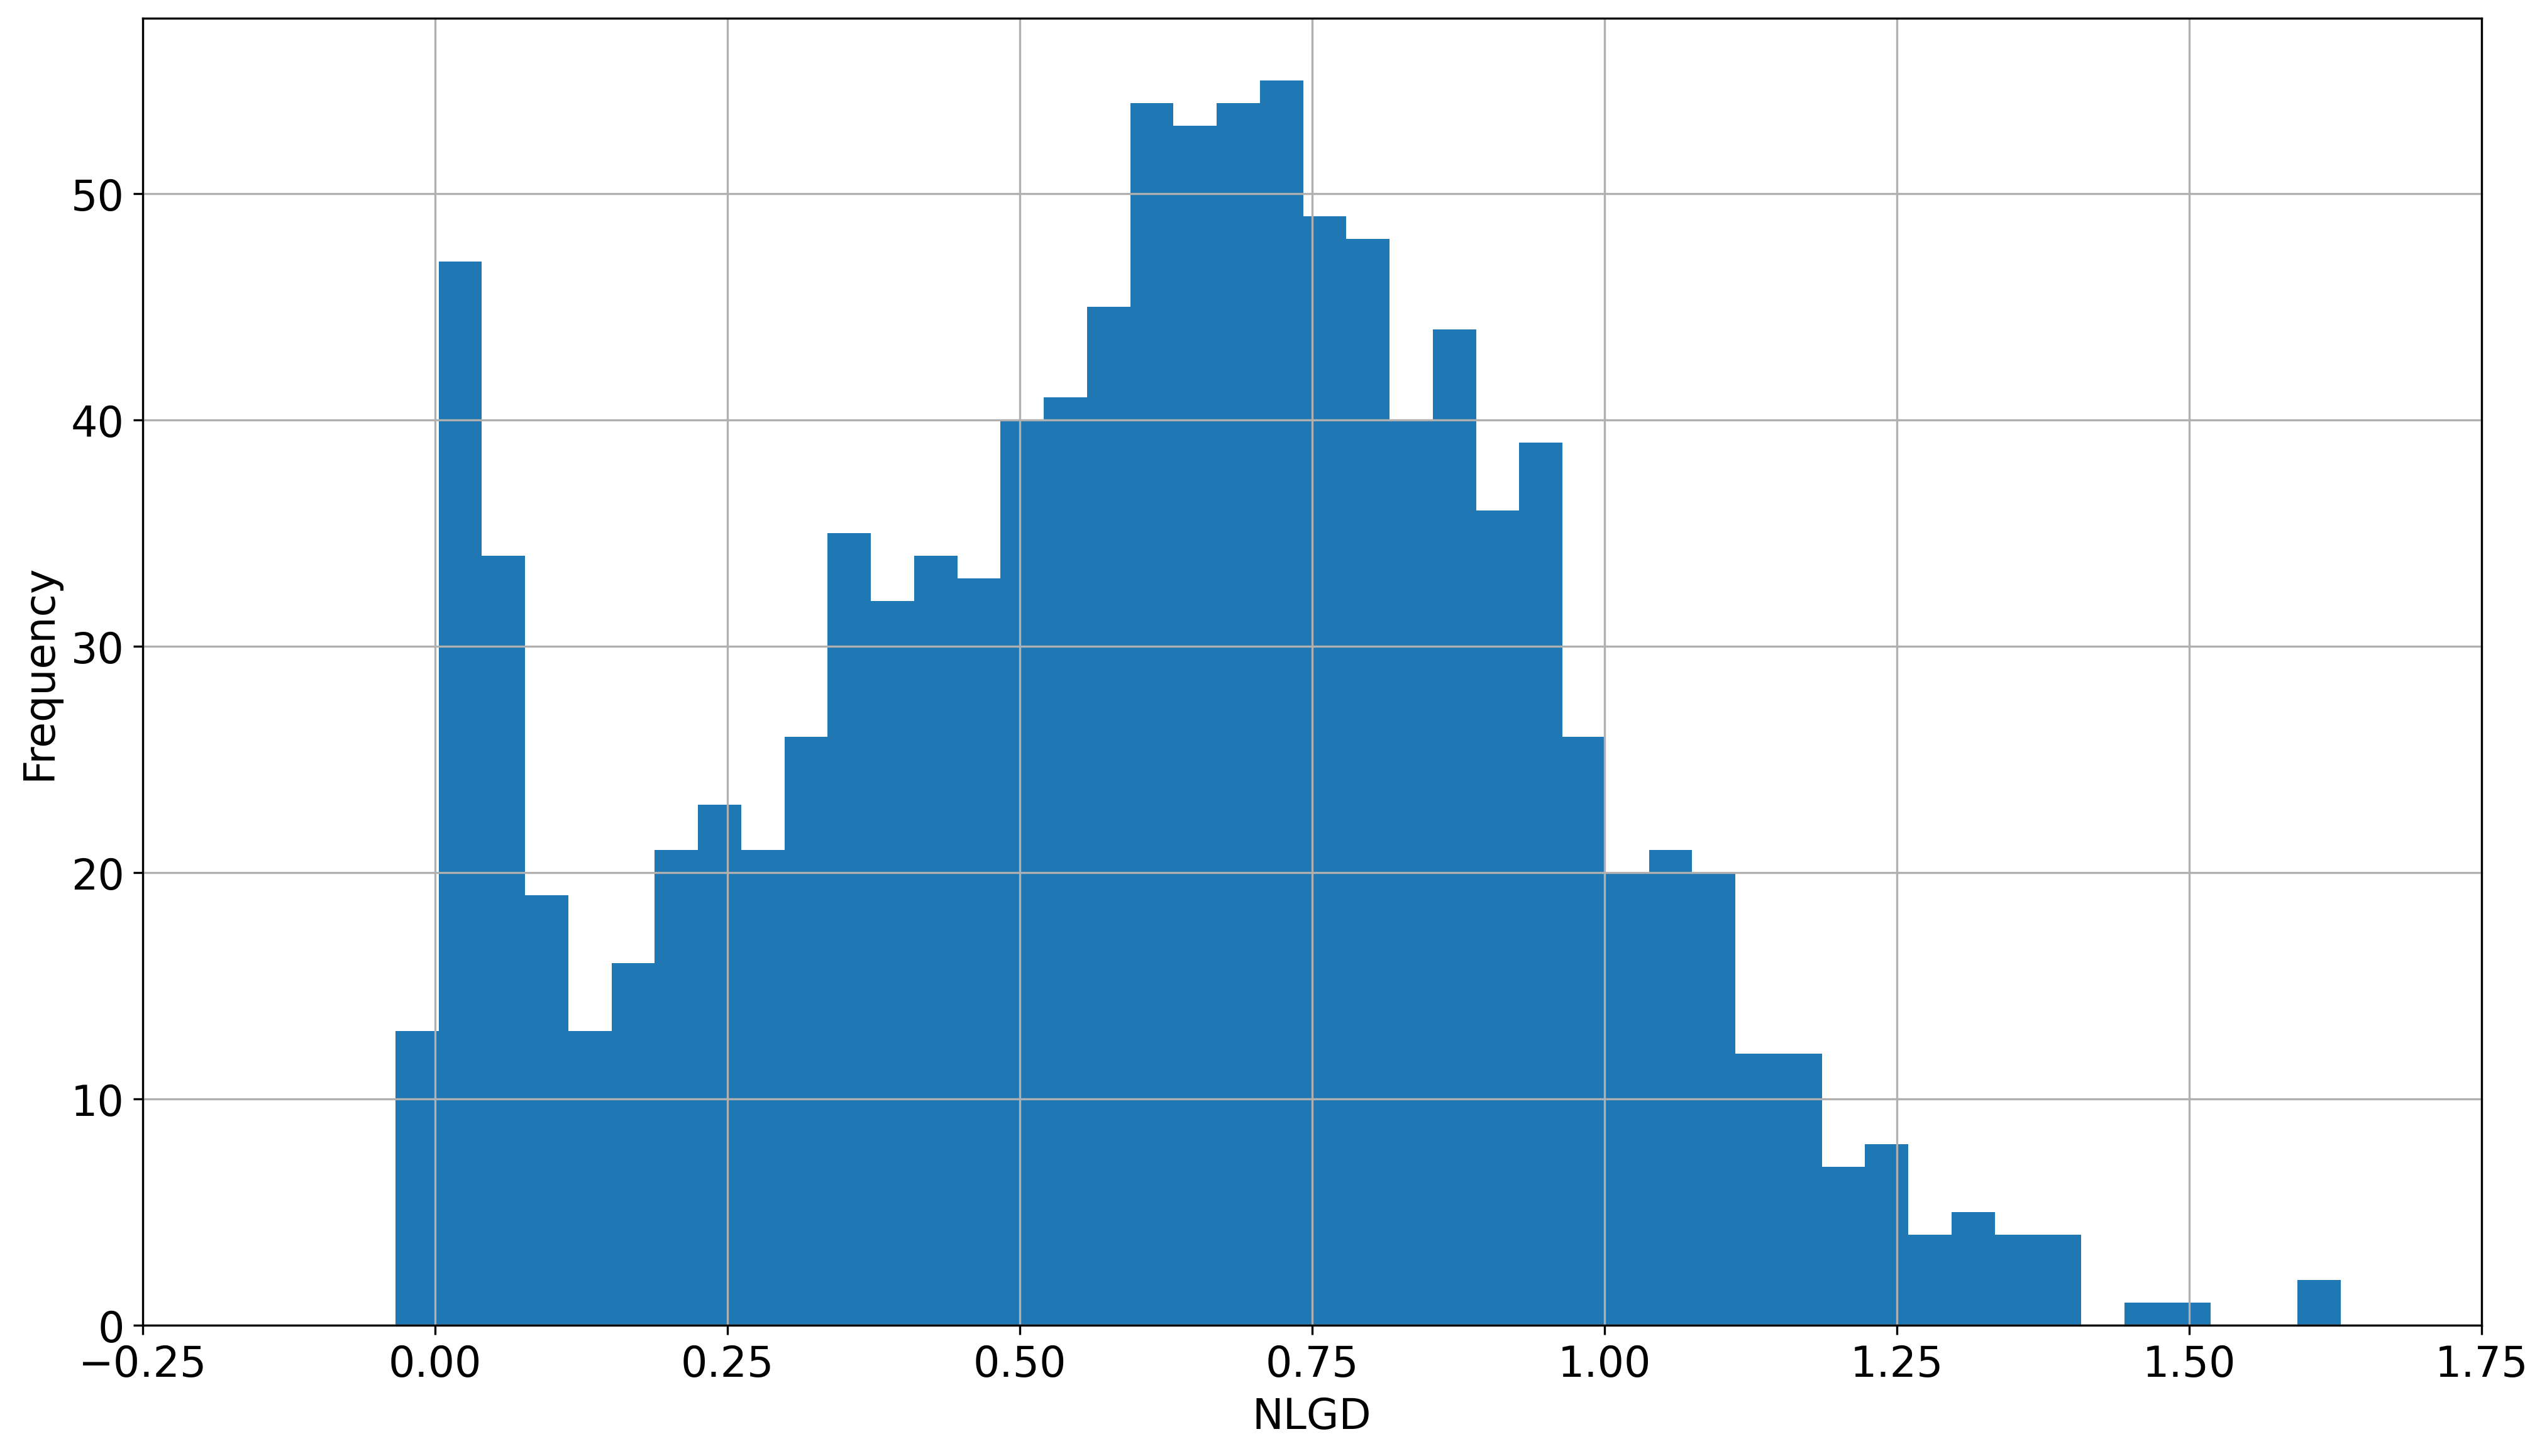

In [19]:
data_default.loc[:,'recovery_res'] = data_default.loc[:,'recovery_res'].astype(float)  
data_default.loc[:,'NLGD'] = (data_default.loc[:,'balance_time'] - data_default.loc[:,'recovery_res'] / (1+data_default.loc[:,'rate_time'] /(100*4) )**data_default.loc[:,'res_period']) / data_default.loc[:,'balance_time']  

data_default.NLGD.hist(bins=50)  
xlim((-0.25, 1.75))  
plt.xlabel('NLGD')  
plt.ylabel('Frequency')  
plt.show() 


In [20]:
print(data_default.NLGD.describe().round(decimals=2)) 

count    1114.00
mean        0.62
std         0.33
min        -0.03
25%         0.39
50%         0.64
75%         0.84
max         1.81
Name: NLGD, dtype: float64


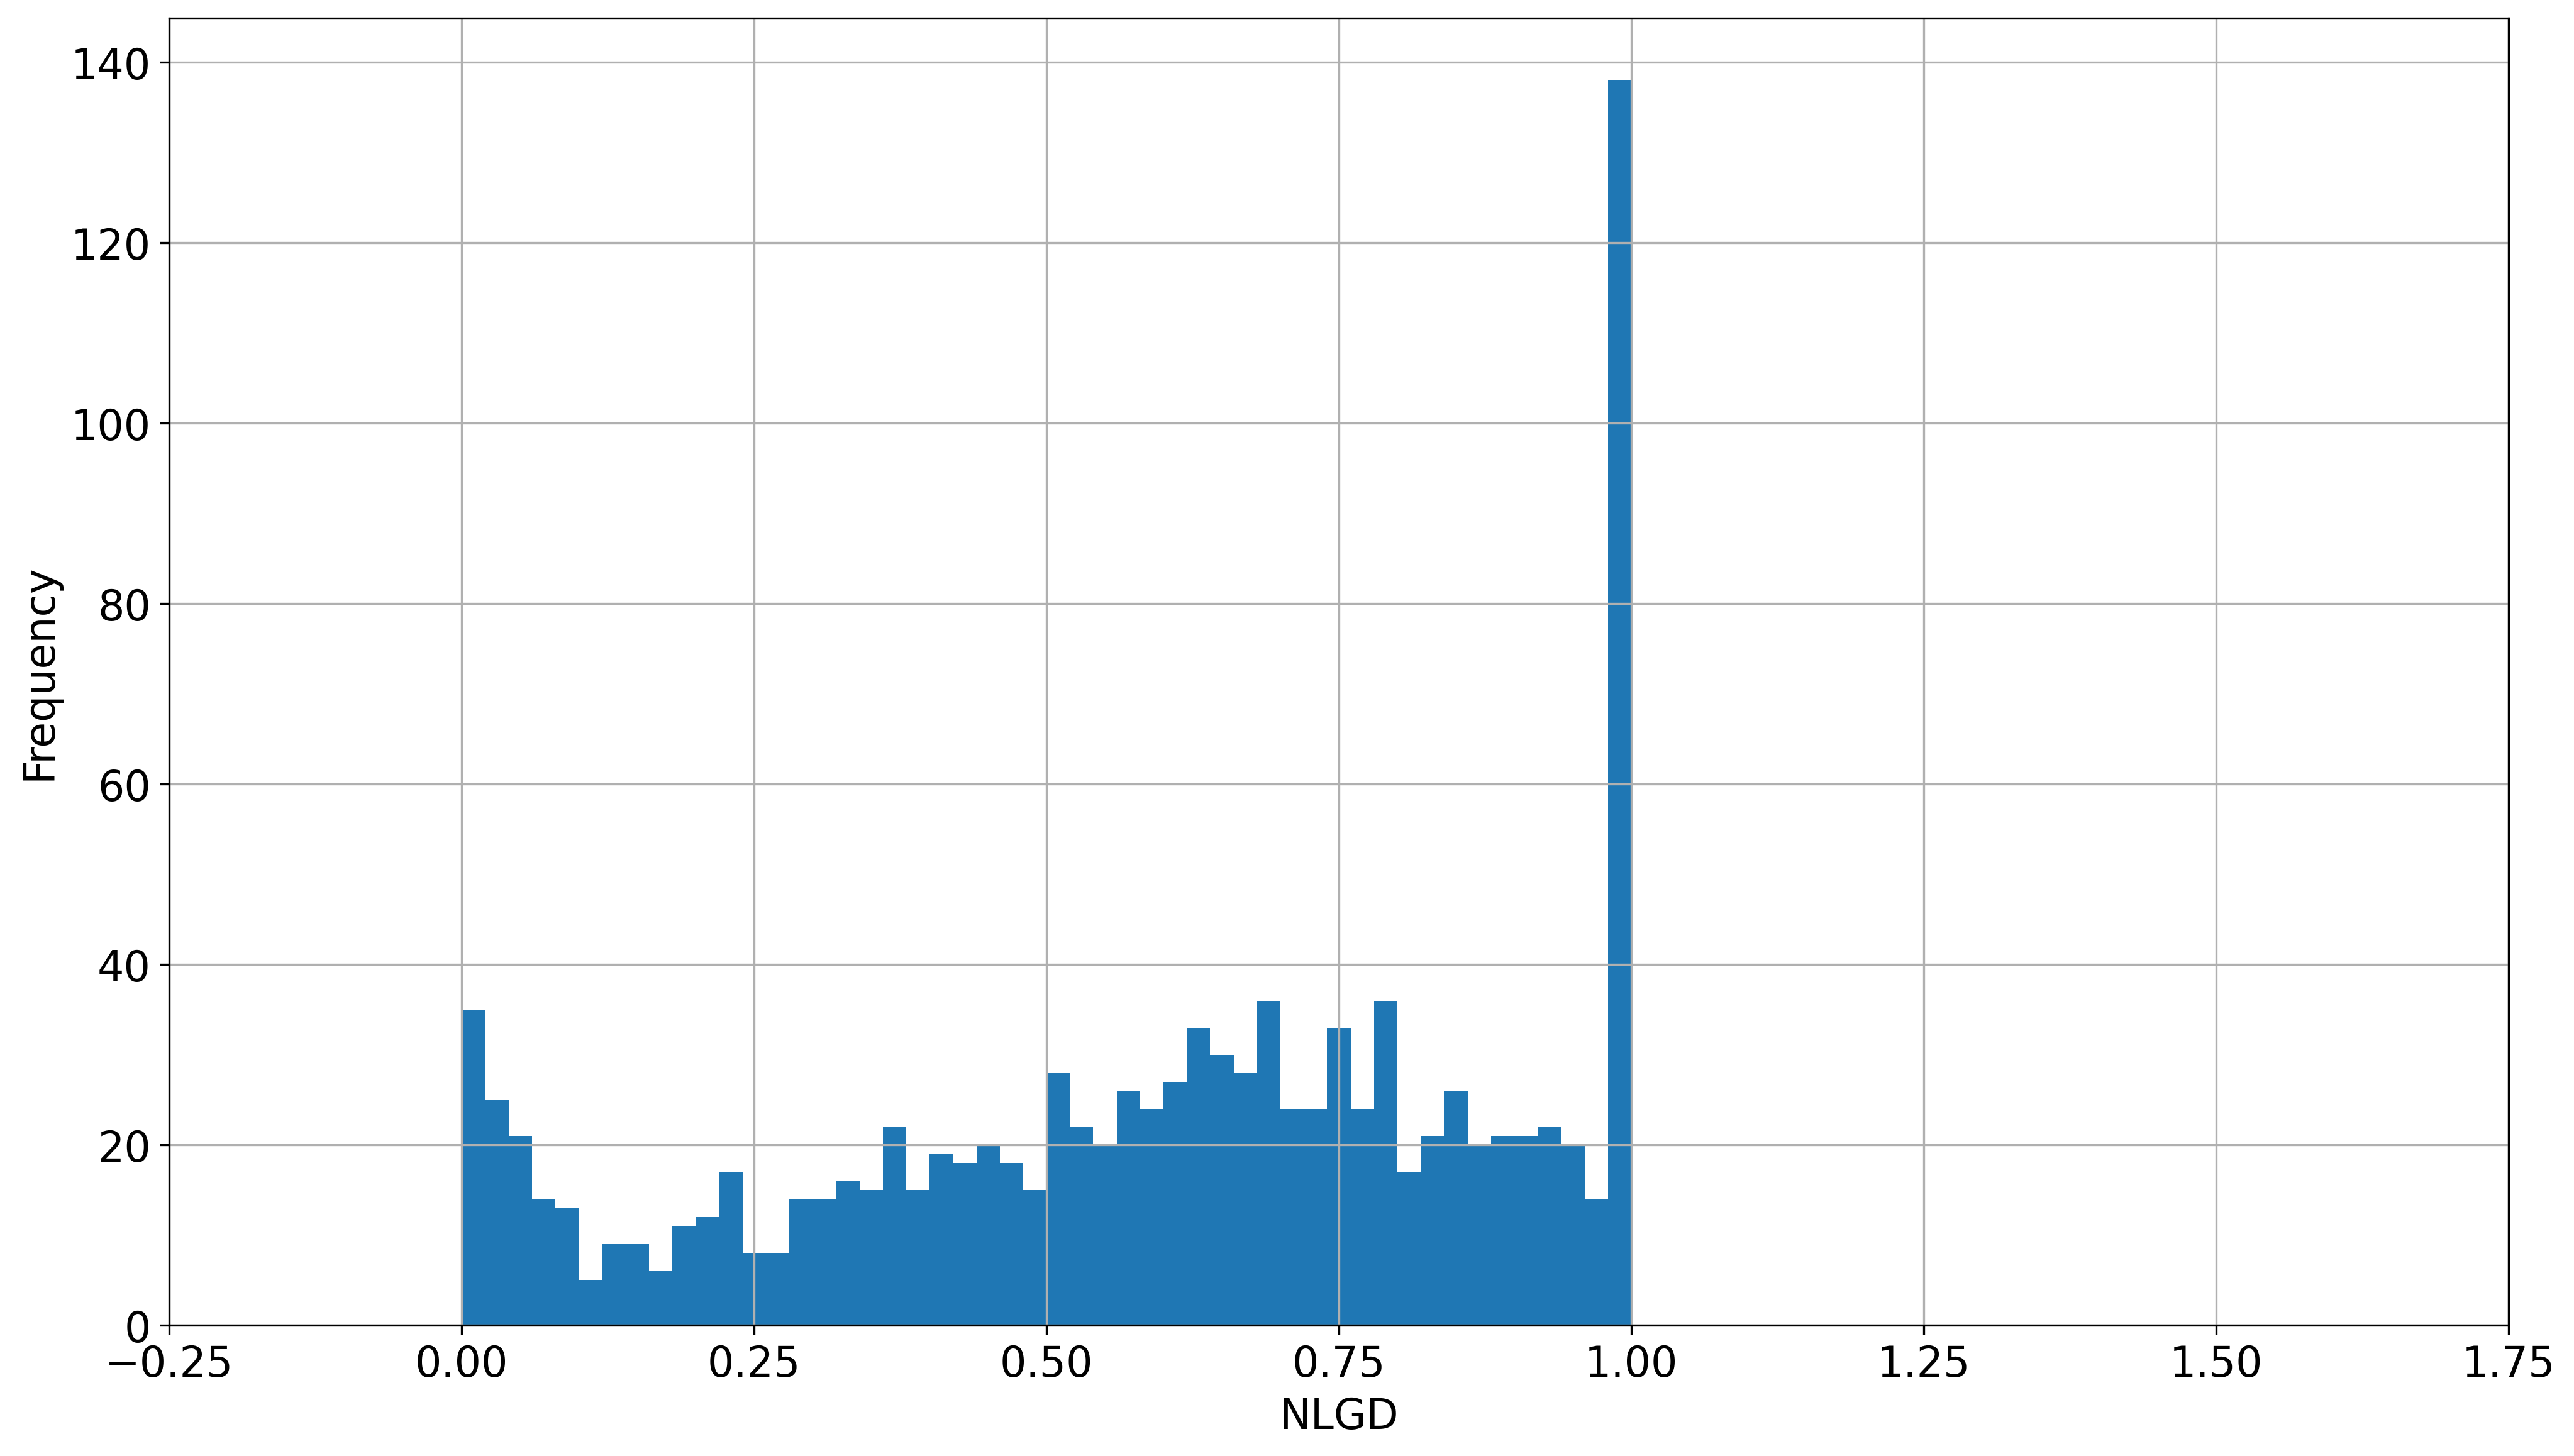

count    1114.00
mean        0.60
std         0.30
min         0.00
25%         0.39
50%         0.64
75%         0.84
max         1.00
Name: NLGD, dtype: float64

In [21]:
data_default.loc[data_default['NLGD'] <= 0, 'NLGD'] = 0.0001  
data_default.loc[data_default['NLGD'] >= 1, 'NLGD'] = 0.9999  

data_default.NLGD.hist(bins=50)  
xlim((-0.25, 1.75))  
plt.xlabel('NLGD')  
plt.ylabel('Frequency')  
plt.show()  

data_default.NLGD.describe().round(decimals=2)  

In [23]:
data_default.loc[:,'discount_period'] = data_default.loc[:,'res_time']-data_default.loc[:,'orig_time']
data_default.loc[data_default['discount_period'] <= 1, 'discount_period'] = 1  
data_default.loc[:,'DR_L'] = (1-data_default.loc[:,'PD']) * data_default.loc[:,'interest_rate_time']/(4*100) + data_default.loc[:,'PD'] * ((1+data_default.loc[:,'interest_rate_time']/(4*100)) * (1-data_default.loc[:,'NLGD']))**(1/data_default.loc[:,  'discount_period']) 

In [24]:
data_default.loc[:,'DLGD'] = 0.2 + 0.8 * data_default.loc[:,'NLGD']  
data_default.loc[:,'equity'] = (data_default.loc[:,'DLGD'] - data_default.loc[:,'NLGD'])/  (1-data_default.loc[:,'NLGD'])  
data_default.loc[:,'debt'] = 1 - data_default.loc[:,'equity']  
data_default.loc[:,'DR_W'] = data_default.loc[:,'equity'] * (data_default.loc[:,'rate_time'  ]/(4*100) + 0.06/4) + data_default.loc[:,'debt'] * (data_default.loc[:,'rate_time'  ]/(4*100) + 0.02/4)

In [25]:
data_default.loc[:,'beta'] = (0.2*np.sqrt(1-0.5))/0.18  
data_default.loc[:,'DR_C'] = data_default.loc[:,'rate_time']/(4*100) + data_default.loc[:,'beta']*0.06/4 

In [26]:
data_default.loc[:,'DR_E'] = data_default.loc[:,'rate_time']/(4*100)+0.05  
data_default.loc[:,'DR_F'] = data_default.loc[:,'rate_time']/(4*100)  

print(data_default[['DR_L', 'DR_W', 'DR_C', 'DR_E', 'DR_F']].dropna().describe().round(decimals=3))  

           DR_L      DR_W      DR_C      DR_E      DR_F
count  1114.000  1114.000  1114.000  1114.000  1114.000
mean      0.041     0.019     0.023     0.062     0.012
std       0.005     0.001     0.001     0.001     0.001
min       0.024     0.016     0.021     0.059     0.009
25%       0.038     0.018     0.023     0.061     0.011
50%       0.041     0.019     0.023     0.062     0.012
75%       0.044     0.019     0.024     0.062     0.012
max       0.058     0.027     0.031     0.070     0.020


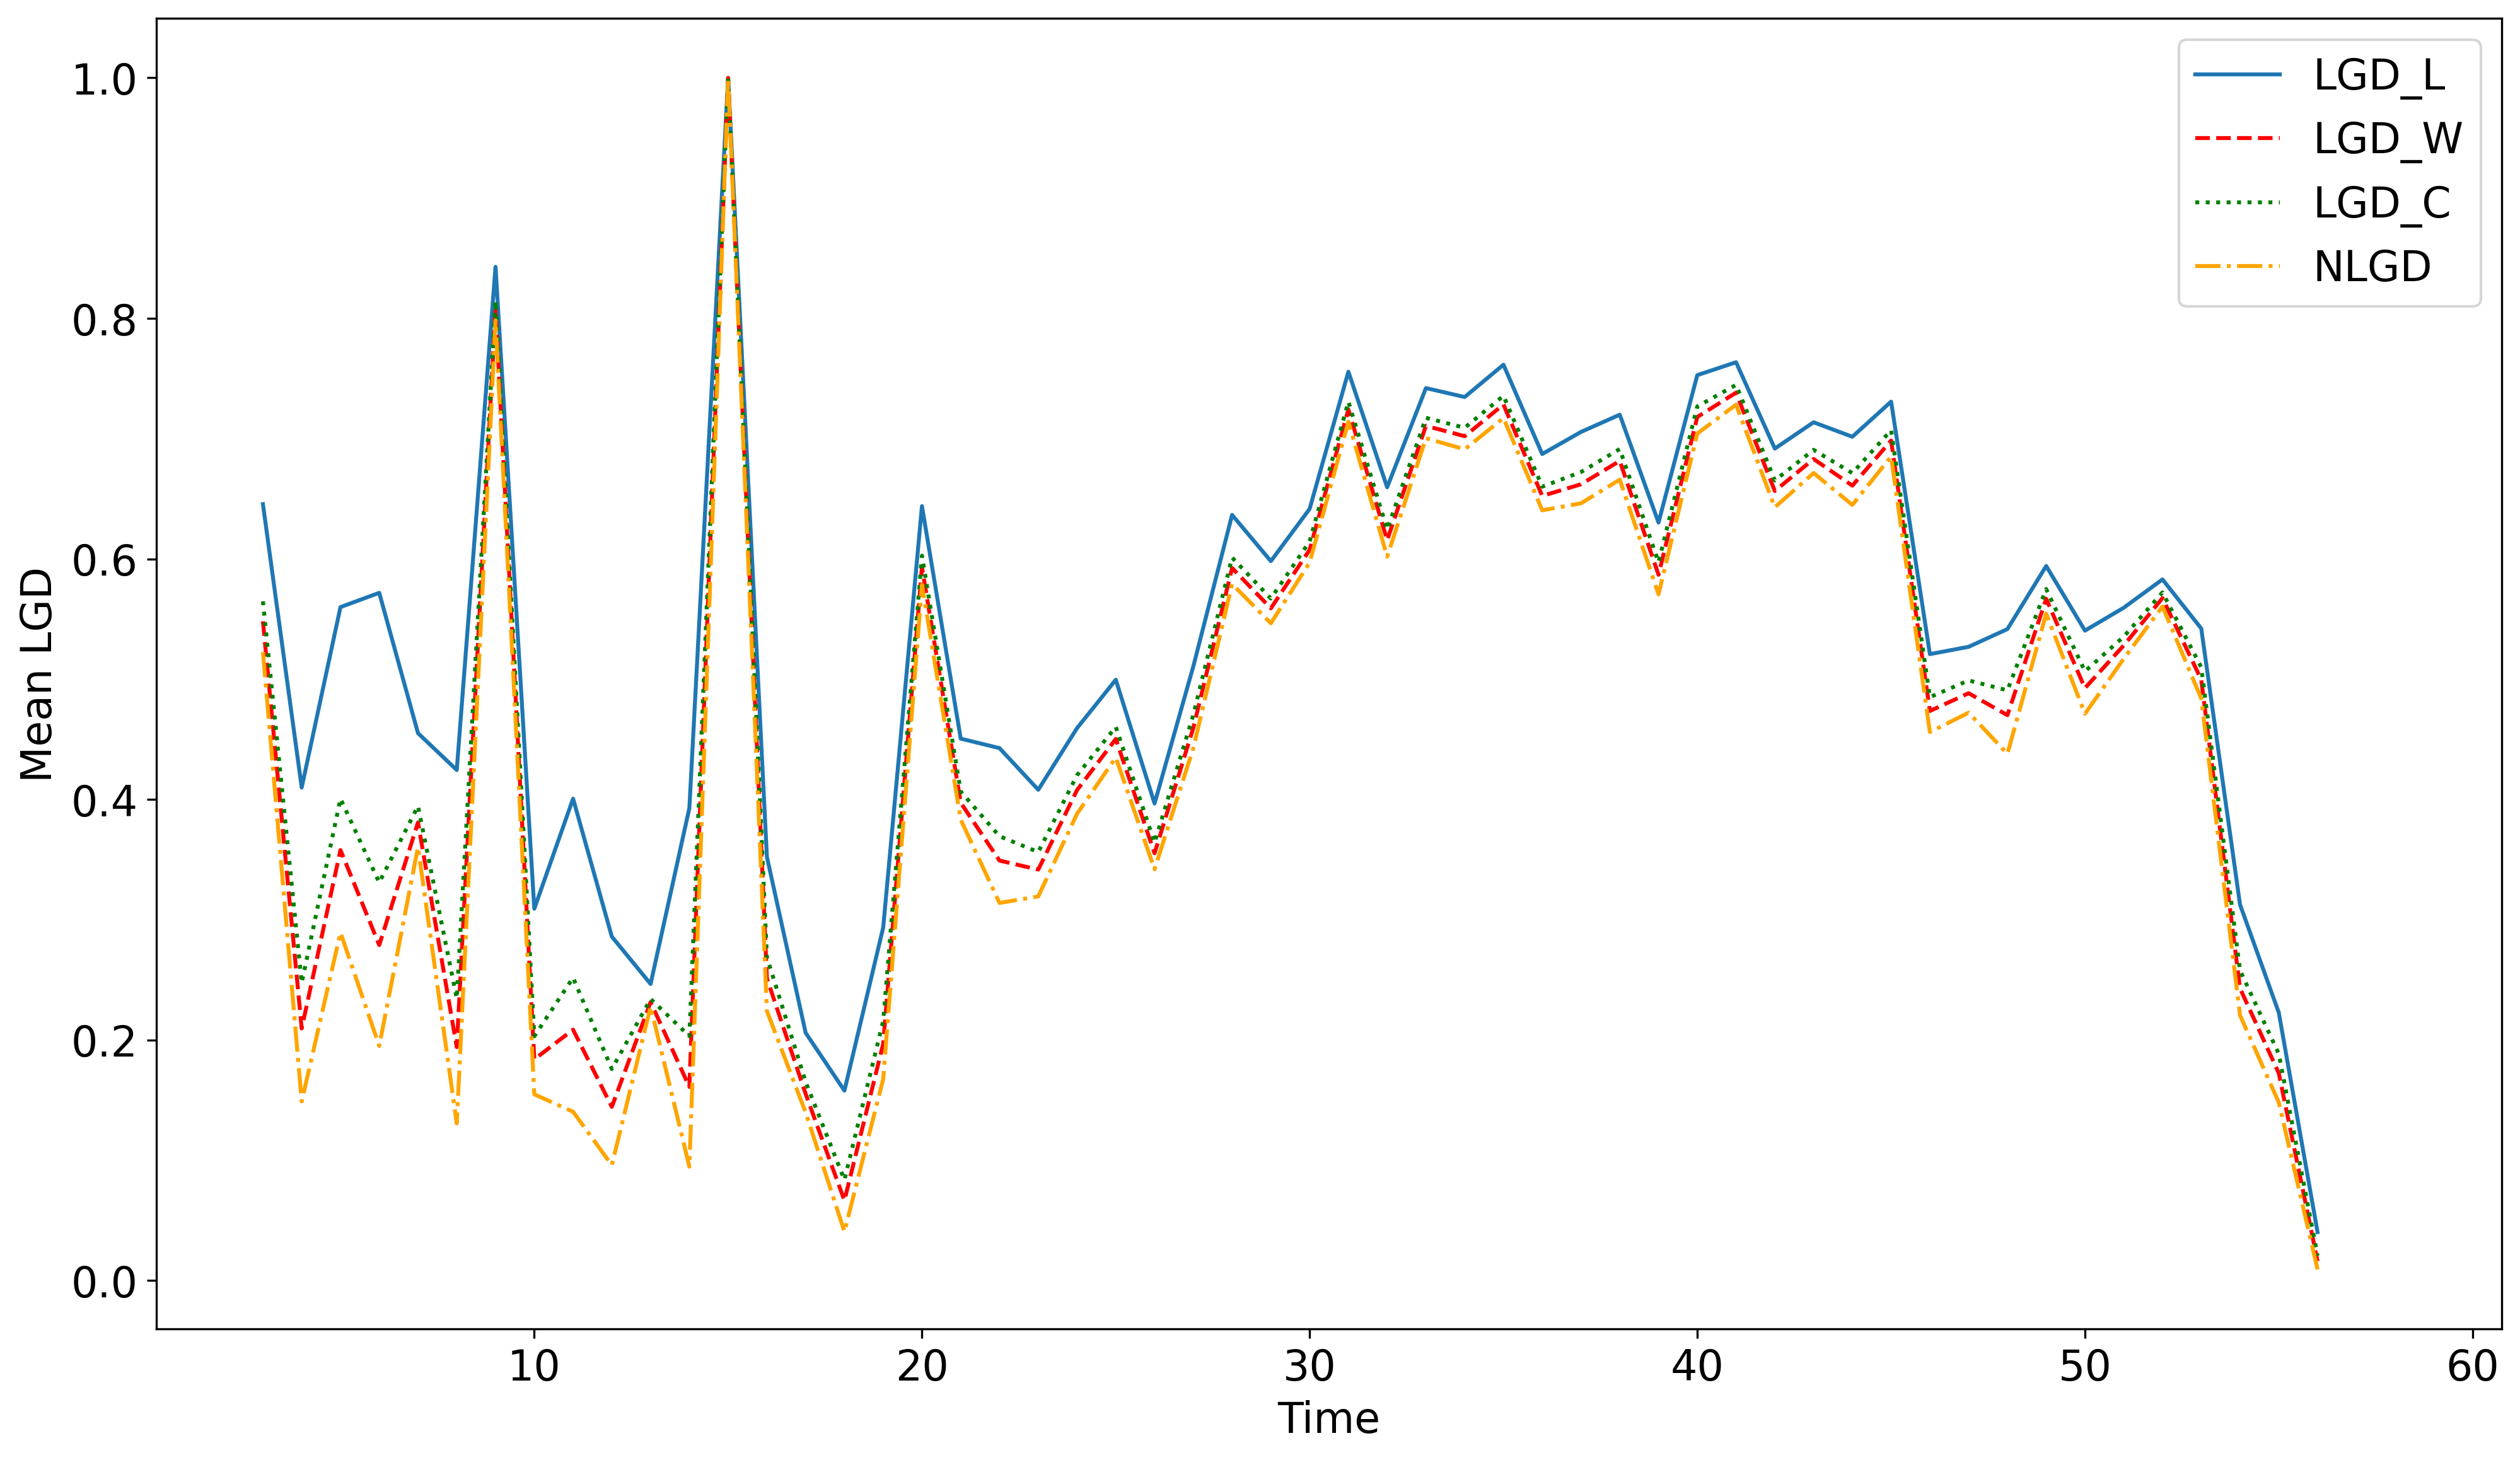

          LGD_L     LGD_W     LGD_C      NLGD
count  1114.000  1114.000  1114.000  1114.000
mean      0.653     0.612     0.621     0.598
std       0.271     0.290     0.286     0.298
min       0.000     0.000     0.000     0.000
25%       0.482     0.410     0.430     0.389
50%       0.699     0.655     0.665     0.637
75%       0.877     0.851     0.856     0.842
max       1.000     1.000     1.000     1.000


In [27]:
data_default.loc[:,'LGD_L'] = (data_default.loc[:,'balance_time'] - data_default.loc[:,'recovery_res']/ (1+data_default.loc[:,'DR_L'])**data_default.loc[:,'res_period'])/  data_default.loc[:,'balance_time']  
data_default.loc[:,'LGD_W'] = (data_default.loc[:,'balance_time'] - data_default.loc[:,'recovery_res']/ (1+data_default.loc[:,'DR_W'])**data_default.loc[:,'res_period'])/  data_default.loc[:,'balance_time']  
data_default.loc[:,'LGD_C'] = (data_default.loc[:,'balance_time'] - data_default.loc[:,'recovery_res']/ (1+data_default.loc[:,'DR_C'])**data_default.loc[:,'res_period'])/  data_default.loc[:,'balance_time']

data_default.loc[data_default['LGD_L'] <= 0, 'LGD_L'] = 0.0001  
data_default.loc[data_default['LGD_L'] >= 1, 'LGD_L'] = 0.9999  
data_default.loc[data_default['LGD_W'] <= 0, 'LGD_W'] = 0.0001  
data_default.loc[data_default['LGD_W'] >= 1, 'LGD_W'] = 0.9999  
data_default.loc[data_default['LGD_C'] <= 0, 'LGD_C'] = 0.0001  
data_default.loc[data_default['LGD_C'] >= 1, 'LGD_C'] = 0.9999  

data_default_mean = data_default.groupby('time')[['LGD_L', 'LGD_W', 'LGD_C', 'NLGD']].mean().reset_index(drop=False)  

plt.plot('time', 'LGD_L', data=data_default_mean, label='LGD_L')  
plt.plot('time', 'LGD_W', data=data_default_mean, color='red', label='LGD_W',linestyle='dashed')  
plt.plot('time', 'LGD_C', data=data_default_mean, color='green', label='LGD_C',linestyle='dotted')  
plt.plot('time', 'NLGD', data=data_default_mean, color='orange', label='NLGD',linestyle='dashdot')  

plt.xlabel('Time')  
plt.ylabel('Mean LGD')  
plt.legend(loc='best')  
plt.show()  

print(data_default[['LGD_L','LGD_W','LGD_C', 'NLGD']].dropna().describe().round(decimals=3)  ) 

In [28]:
print(data_default[['NLGD', 'res_period']].corr(method='pearson').round(decimals=2))

            NLGD  res_period
NLGD        1.00        0.36
res_period  0.36        1.00


In [29]:
data_default2 = data_default.dropna(subset=['res_time']).copy()  
data_default2.loc[data_default2['res_period'] >= 20, 'res_period'] = 20

data_LGD_sum = data_default2.groupby('res_period')[['LGD_L', 'LGD_W', 'LGD_C', 'NLGD']].sum()  
print(data_LGD_sum) 


                LGD_L      LGD_W      LGD_C       NLGD
res_period                                            
0.0          0.002508   0.002508   0.002508   0.002508
1.0         17.362085  16.483746  16.654468  16.231093
2.0         55.114900  52.401376  52.966808  51.559721
3.0         80.692028  75.867710  76.890208  74.339029
4.0         93.815828  87.903977  89.168858  85.999218
...               ...        ...        ...        ...
16.0        13.124066  12.052094  12.264820  11.708645
17.0         8.879712   7.860787   8.101097   7.470516
18.0         6.170947   5.270728   5.491194   4.910638
19.0         7.939292   7.373545   7.512135   7.145812
20.0        33.305032  30.278093  30.980998  29.084828

[21 rows x 4 columns]


In [30]:
data_LGD_count = data_default2.groupby('res_period')[['LGD_L', 'LGD_W', 'LGD_C', 'NLGD']].count()  
print(data_LGD_count)  

            LGD_L  LGD_W  LGD_C  NLGD
res_period                           
0.0            12     12     12    12
1.0            53     53     53    53
2.0           113    113    113   113
3.0           150    150    150   150
4.0           156    156    156   156
...           ...    ...    ...   ...
16.0           15     15     15    15
17.0           11     11     11    11
18.0            8      8      8     8
19.0            9      9      9     9
20.0           37     37     37    37

[21 rows x 4 columns]


In [31]:
data_LGD_sum = data_LGD_sum.sort_values(by='res_period', ascending=False)  
data_LGD_count = data_LGD_count.sort_values(by='res_period', ascending=False)  

data_LGD_sum_cumsum = data_LGD_sum.cumsum()  
data_LGD_count_cumsum = data_LGD_count.cumsum()  
data_LGD_mean = data_LGD_sum_cumsum / data_LGD_count_cumsum

print(data_LGD_mean.round(4))

             LGD_L   LGD_W   LGD_C    NLGD
res_period                                
20.0        0.9001  0.8183  0.8373  0.7861
19.0        0.8966  0.8185  0.8368  0.7876
18.0        0.8781  0.7949  0.8145  0.7619
17.0        0.8661  0.7813  0.8013  0.7479
16.0        0.8677  0.7854  0.8044  0.7540
...            ...     ...     ...     ...
4.0         0.7310  0.6831  0.6938  0.6663
3.0         0.7001  0.6547  0.6648  0.6390
2.0         0.6772  0.6341  0.6436  0.6193
1.0         0.6604  0.6186  0.6278  0.6042
0.0         0.6533  0.6119  0.6210  0.5977

[21 rows x 4 columns]


In [36]:
data_LGD_mean = data_LGD_mean.iloc[:, 0:4]
data_LGD_mean['time'] = 61 - data_LGD_mean.index
data_LGD_mean = data_LGD_mean.set_index('time')

data_LGD_mean2 = data_LGD_mean.iloc[[0]].copy()
data_LGD_mean2 = pd.concat([data_LGD_mean2] * 41)

data_LGD_mean2 = data_LGD_mean2.reset_index()
data_LGD_mean_reset = data_LGD_mean.reset_index()
data_LGD_mean3 = pd.concat([data_LGD_mean2, data_LGD_mean_reset], ignore_index=True)

data_default_replace = data_default[data_default['res_time'].isnull()].drop(
    ['res_period', 'LGD_L', 'LGD_W', 'LGD_C', 'NLGD'], axis=1
)

data_default_replace2 = pd.merge(data_default_replace, data_LGD_mean3, on='time')

In [37]:
data_default2 = data_default2[data_default_replace2.columns]
print(data_default2.shape)

data_default3 = pd.concat([data_default2, data_default_replace2], ignore_index=True)
print(data_default3.shape)

(1114, 62)
(1115, 62)


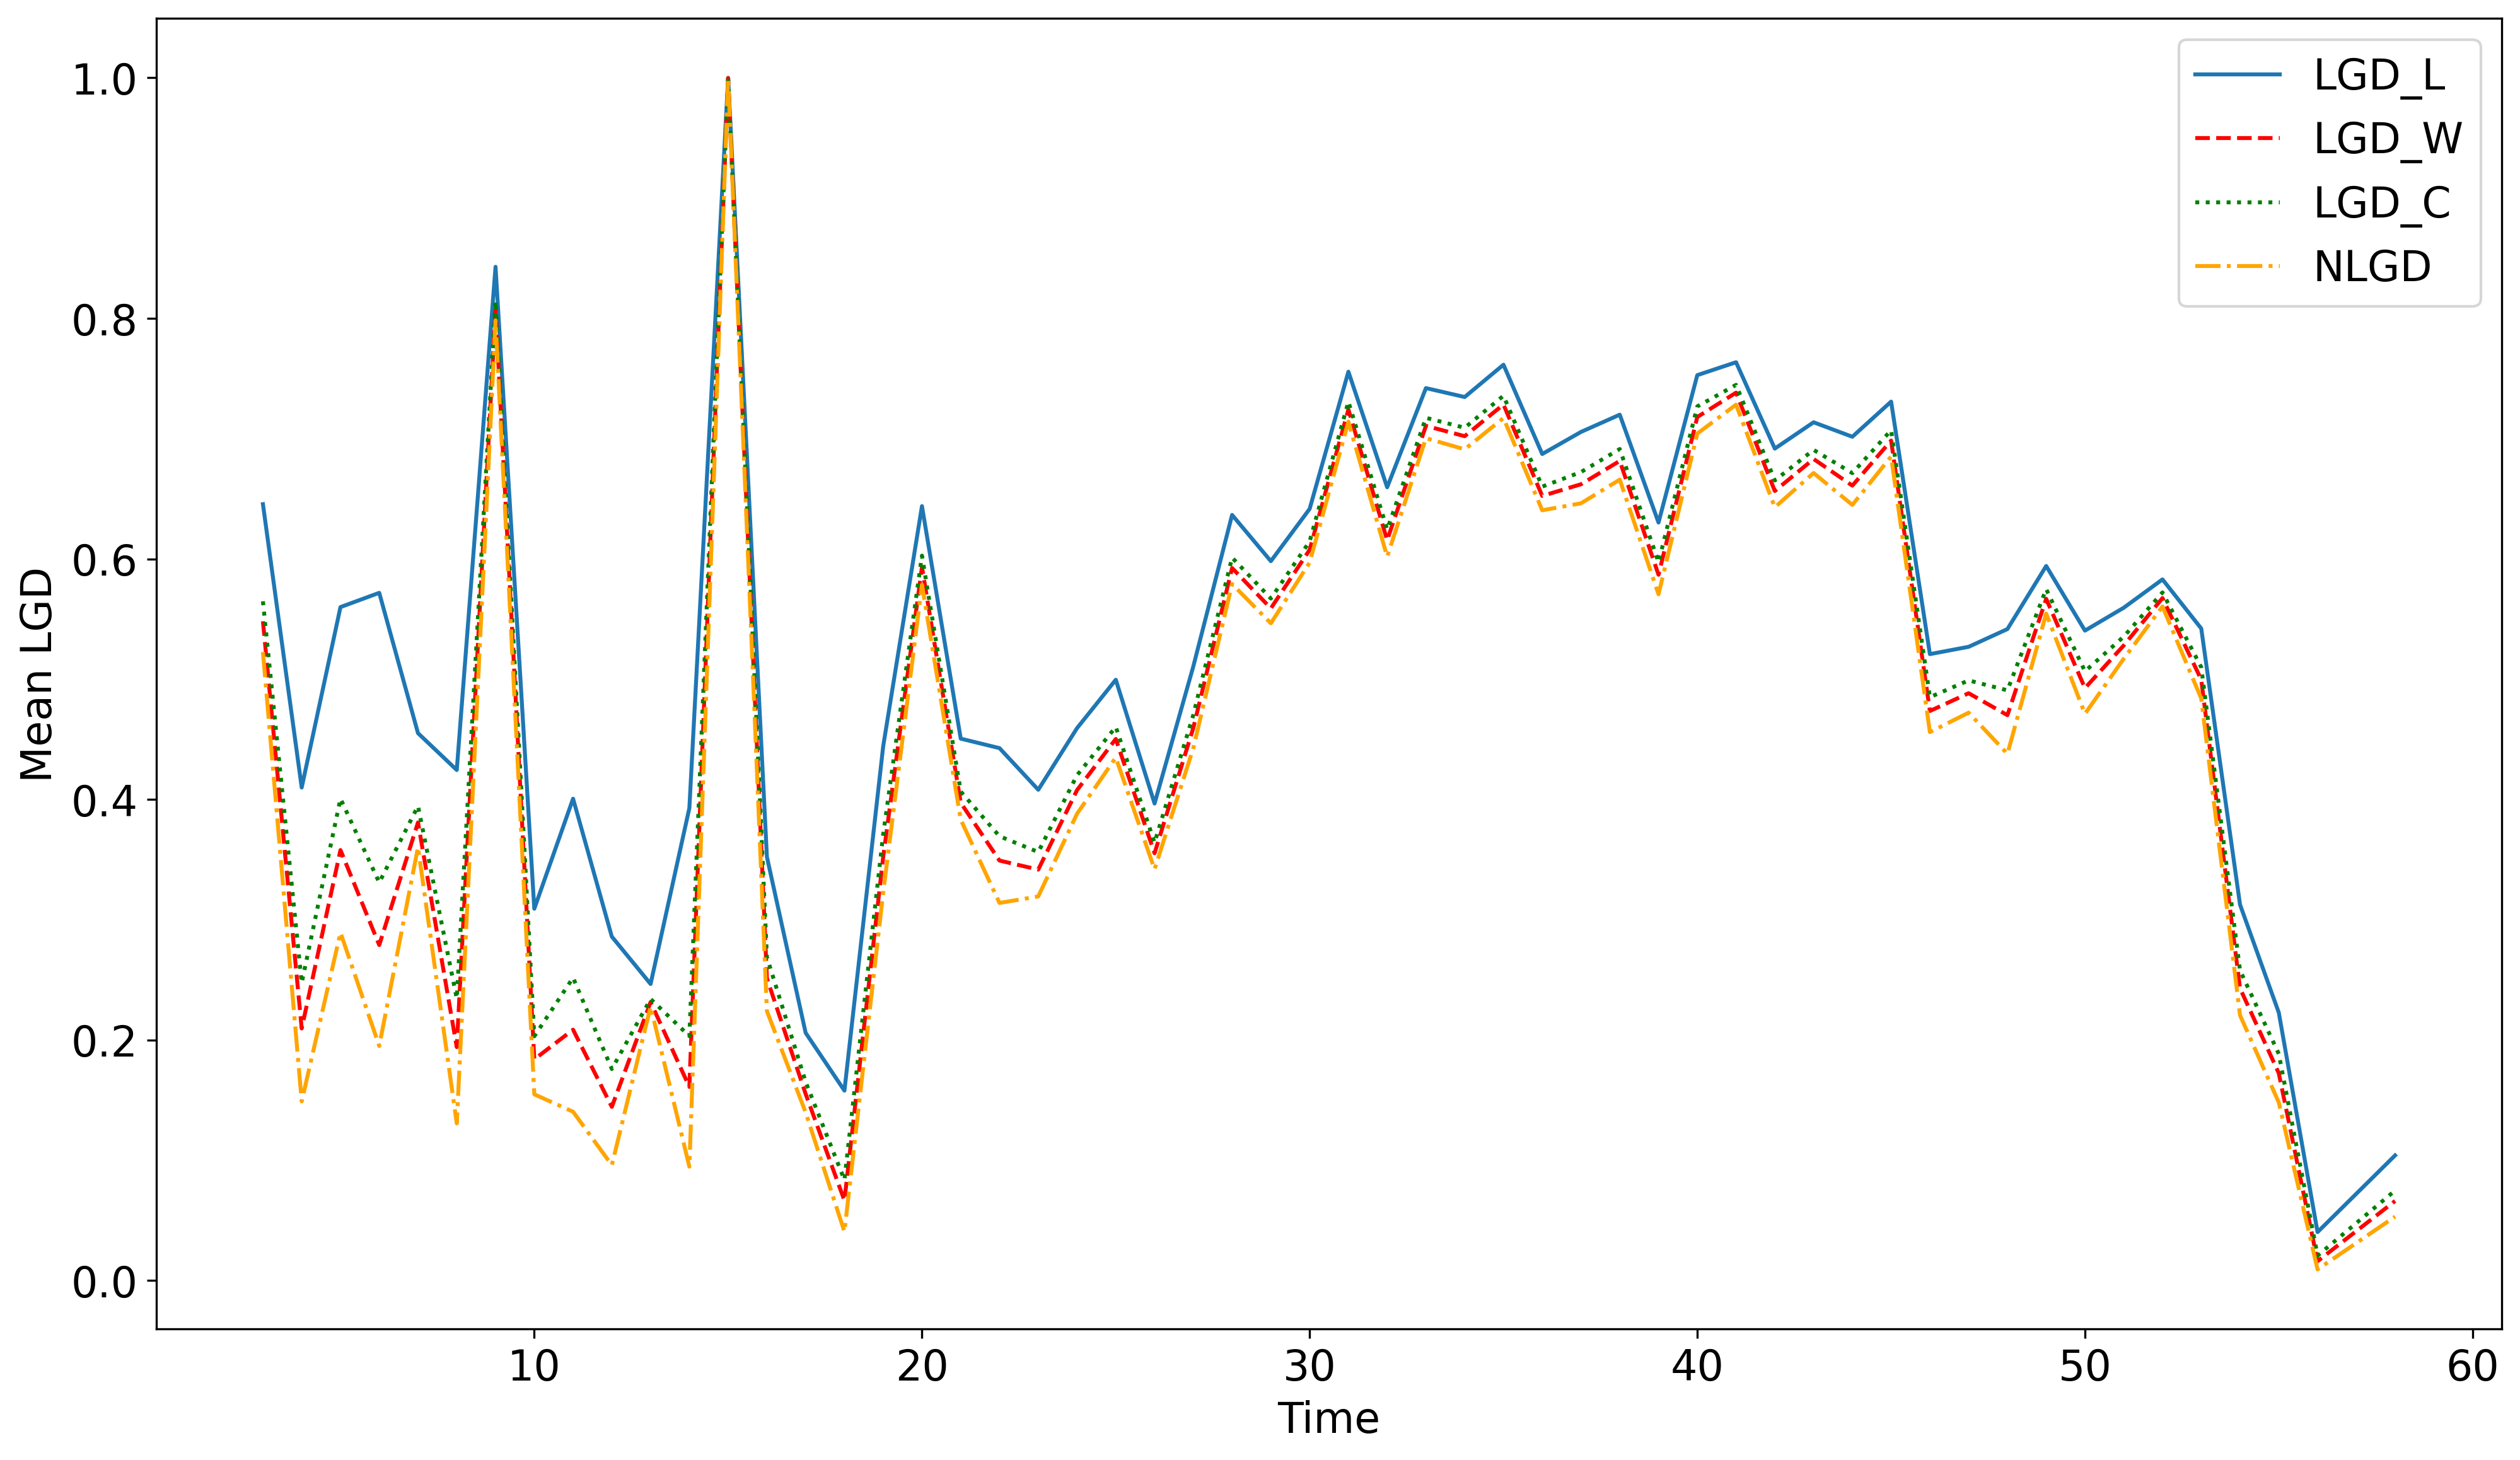

In [39]:
data_default3_mean = data_default3.groupby('time')[['LGD_L', 'LGD_W', 'LGD_C', 'NLGD']].mean().reset_index(drop=False)  

plt.plot('time', 'LGD_L', data=data_default3_mean, label='LGD_L')  
plt.plot('time', 'LGD_W', data=data_default3_mean, color='red', label='LGD_W',linestyle='dashed')  
plt.plot('time', 'LGD_C', data=data_default3_mean, color='green', label='LGD_C',linestyle='dotted')  
plt.plot('time', 'NLGD', data=data_default3_mean, color='orange', label='NLGD',linestyle='dashdot')  
plt.xlabel('Time')  
plt.ylabel('Mean LGD')  
plt.legend(loc='best')  
plt.show()  
#print(data_default3[{'LGD_L','LGD_W','LGD_C', 'NLGD'}].dropna().describe().round(decimals=3)) 


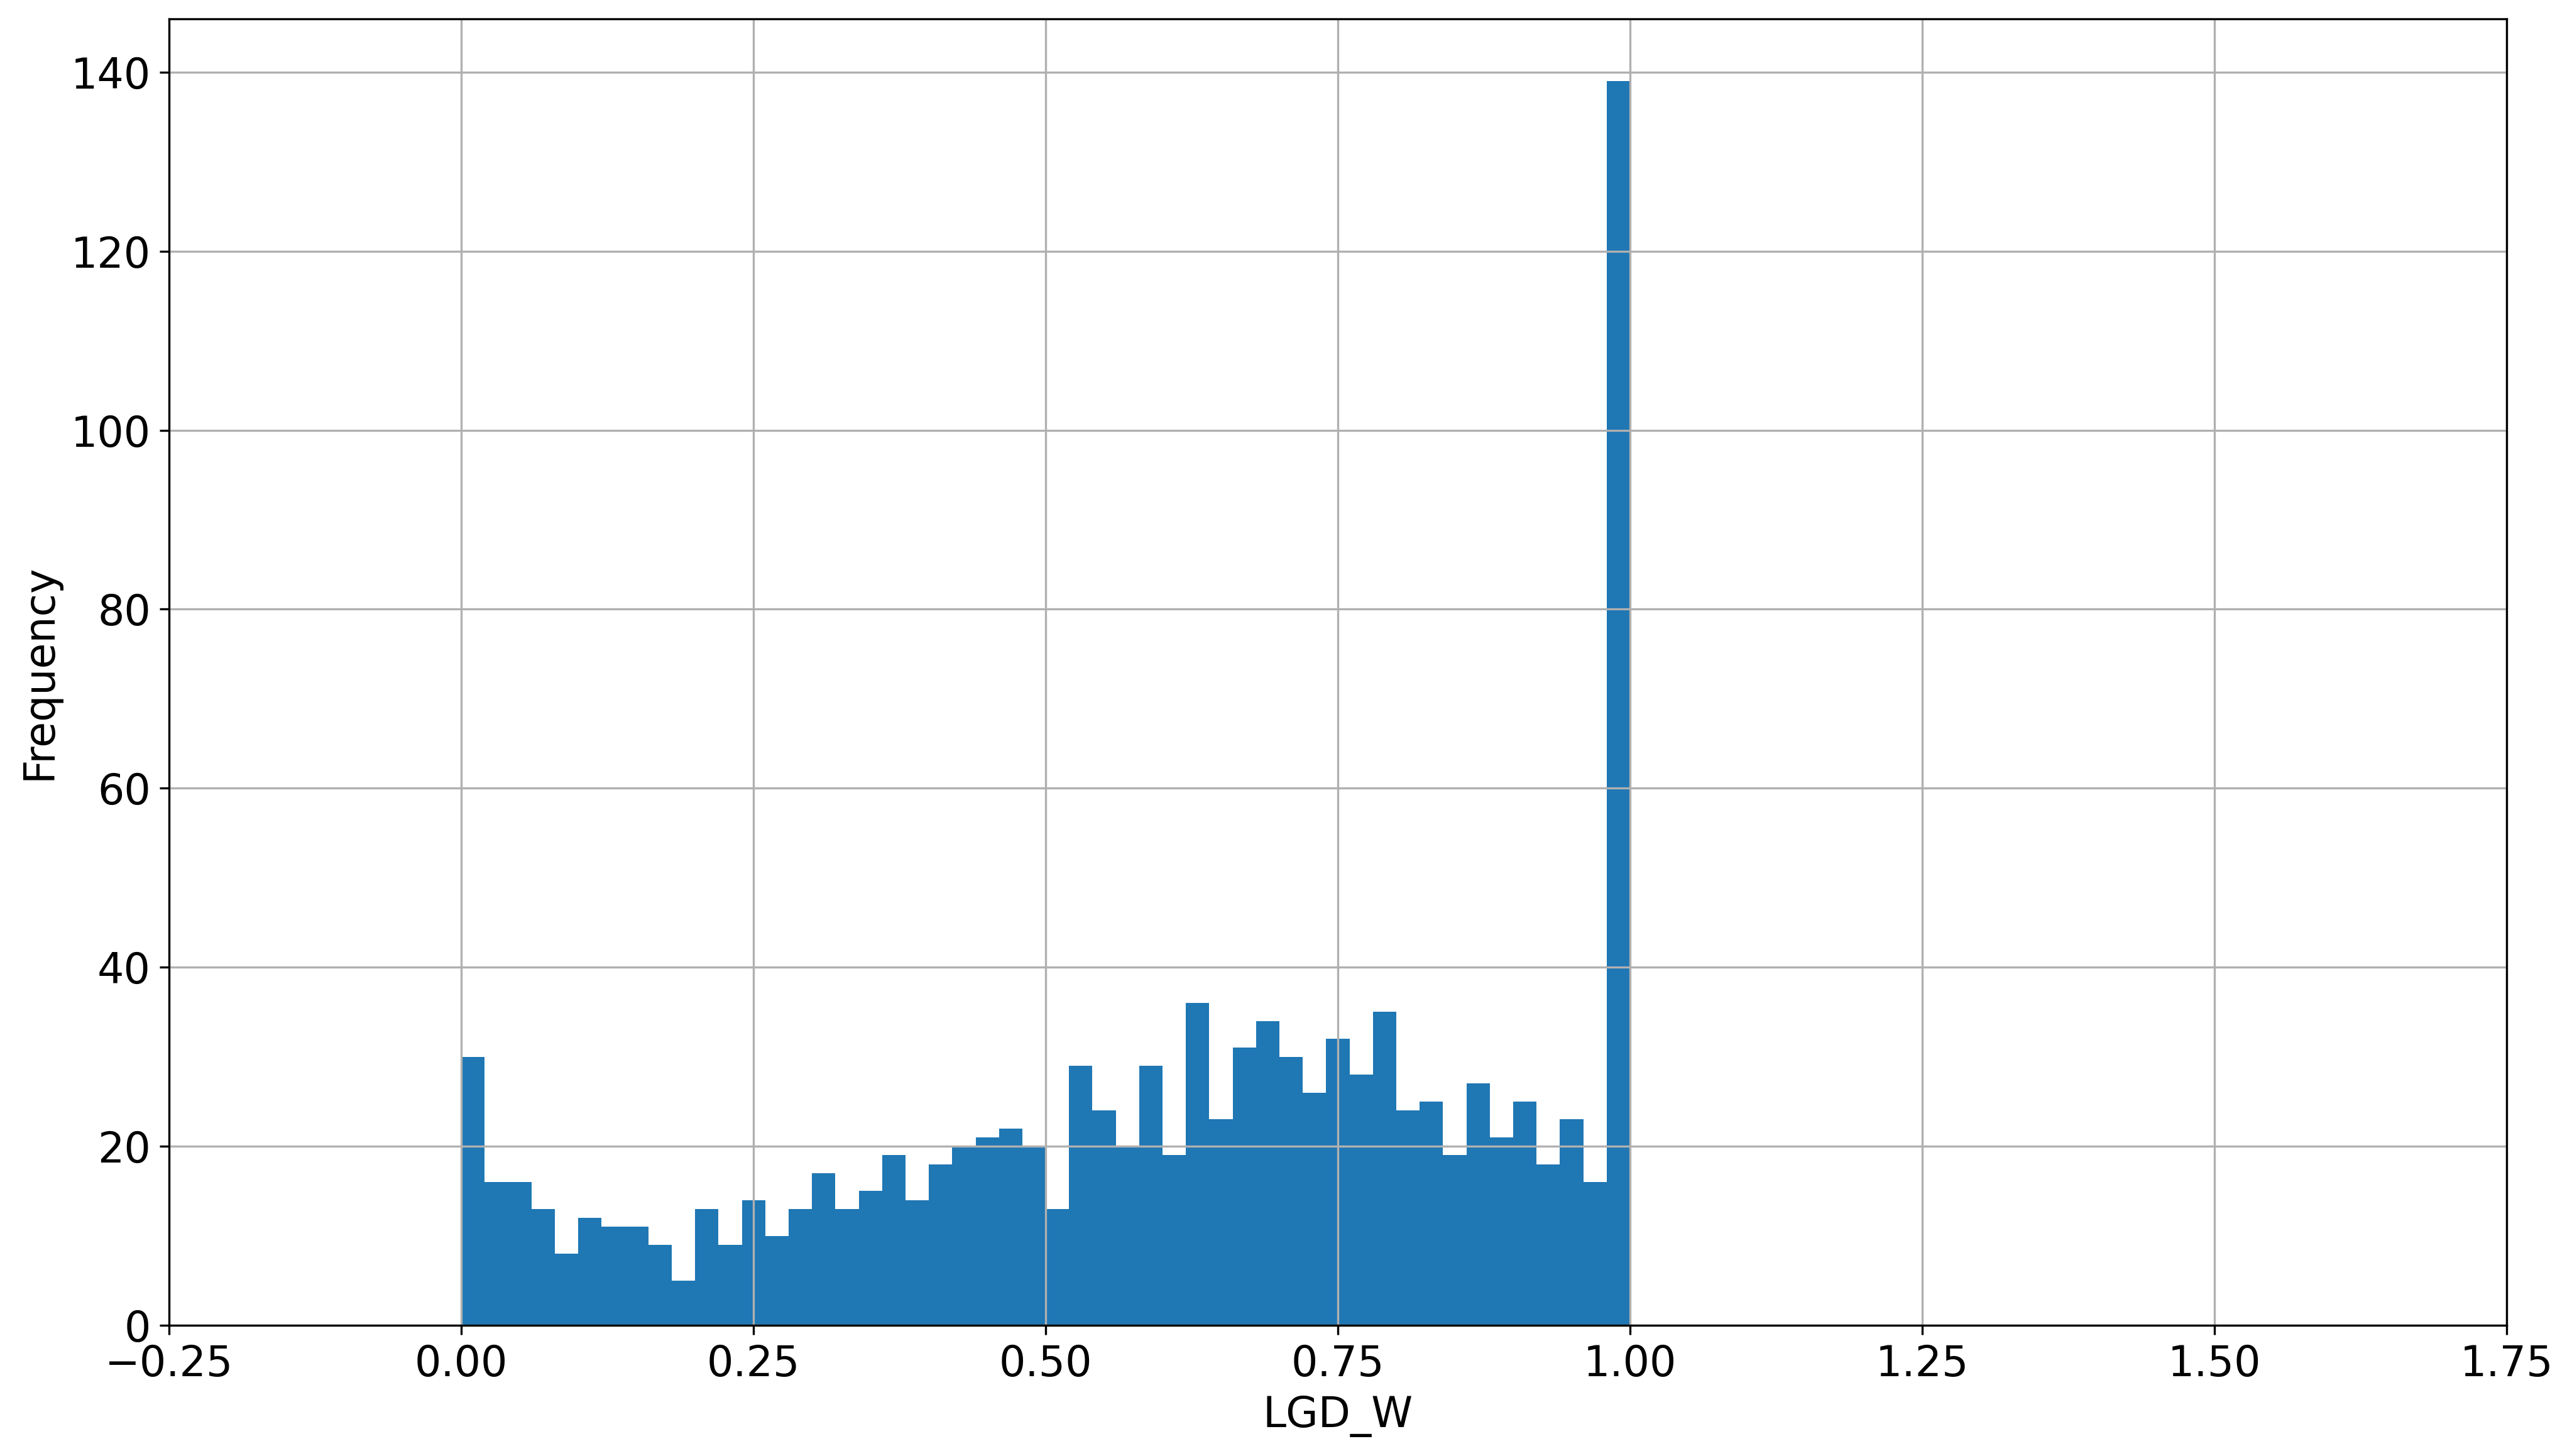

In [40]:
data_default3.LGD_W.hist(bins=50)  
xlim((-0.25, 1.75))  
plt.xlabel('LGD_W')  
plt.ylabel('Frequency')  
plt.show() 

In [41]:
data_default = data_default.drop('res_period', axis='columns').copy()  
data_default = resolutionbias(data_default, 'LGD_W', 'res_time', 'time')  
data_default = resolutionbias(data_default, 'LGD_L', 'res_time', 'time')  
data_default = resolutionbias(data_default, 'LGD_C', 'res_time', 'time')  
data_default = resolutionbias(data_default, 'NLGD', 'res_time', 'time') 